# Home Credit Default Risk — Pipeline: Data Cleaning → Feature Engineering → Model → Evaluation

**Mục tiêu:** Xây dựng pipeline cơ bản, đầy đủ từ đầu đến cuối, dựa trên các phát hiện từ notebook EDA trước đó:
1. **Data Cleaning** — xử lý giá trị bất thường (`DAYS_EMPLOYED=365243`), gộp nhóm hiếm (rare categories).
2. **Feature Engineering** — tạo đặc trưng theo từng nhóm (tỷ lệ tài chính, tổ hợp EXT_SOURCE, đặc trưng thời gian/hành vi từ các bảng phụ), **ghép bảng theo khoá ngoại**, và với các bảng dài dạng "_balance" (`bureau_balance`, `POS_CASH_balance`, `credit_card_balance`) tính thêm **đặc trưng theo cửa sổ thời gian và xu hướng (trend)**.
3. **Kiểm tra lại** tương quan của feature mới với `TARGET` + feature importance.
4. **Model** — LightGBM, tham số cơ bản (chưa hyperparameter tuning).
5. **Evaluation** — Confusion Matrix, Precision/Recall/Accuracy, ROC-AUC, Precision-Recall curve, Feature Importance.

> **Nguyên tắc thiết kế:** mỗi bước tạo đặc trưng đều có markdown giải thích **ý nghĩa nghiệp vụ**, để sau này dễ mở rộng — chỉ cần thêm cell mới vào đúng mục tương ứng (ví dụ muốn thêm đặc trưng bureau mới → sửa ở Phần 5).

**Cấu trúc notebook:**

| Phần | Nội dung |
|---|---|
| 1 | Setup & Load dữ liệu |
| 2 | Data Cleaning — `application_train/test` |
| 3 | Feature Engineering — `application` (tỷ lệ, tổ hợp EXT_SOURCE, thời gian) |
| 4 | Feature Engineering — `bureau` + `bureau_balance` (ghép bảng, trend) |
| 5 | Feature Engineering — `previous_application` |
| 6 | Feature Engineering — `POS_CASH_balance` (trend) |
| 7 | Feature Engineering — `installments_payments` |
| 8 | Feature Engineering — `credit_card_balance` (trend) |
| 9 | Ghép toàn bộ feature về bảng master (theo `SK_ID_CURR`) |
| 10 | Kiểm tra tương quan feature mới với TARGET |
| 11 | Làm sạch lần cuối trước khi vào model (inf, encoding, split) |
| 12 | Train/Validation split |
| 13 | Model — LightGBM baseline |
| 14 | Evaluation — Confusion Matrix, Precision/Recall/Accuracy, ROC-AUC |
| 15 | Feature Importance — đối chiếu lại với EDA |
| 16 | (Bonus) Dự đoán trên tập test |
| 17 | Kết luận & hướng mở rộng |


## 1. Setup & Load dữ liệu

**Yêu cầu môi trường:** `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`, `lightgbm` (đều có sẵn trên Kaggle Notebook).

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import gc
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, roc_curve, auc,
    confusion_matrix, classification_report,
    precision_score, recall_score, accuracy_score, f1_score,
    precision_recall_curve,
)

try:
    import lightgbm as lgb
except ImportError:
    import sys
    print('Đang cài lightgbm...')
    os.system(f'{sys.executable} -m pip install lightgbm --quiet')
    import lightgbm as lgb

pd.set_option('display.max_columns', 250)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('lightgbm version:', lgb.__version__)

lightgbm version: 4.6.0


In [2]:
# TODO: chỉnh lại đường dẫn cho phù hợp với môi trường chạy (Kaggle / local)
DATA_DIR = '/kaggle/input/competitions/home-credit-default-risk'

if not os.path.exists(DATA_DIR):
    candidates = ['../input/home-credit-default-risk/', './data/', './']
    for c in candidates:
        if os.path.exists(os.path.join(c, 'application_train.csv')):
            DATA_DIR = c
            break

print('DATA_DIR =', DATA_DIR)
print(os.listdir(DATA_DIR) if os.path.exists(DATA_DIR) else 'Thư mục chưa tồn tại - vui lòng cập nhật DATA_DIR')

DATA_DIR = /kaggle/input/competitions/home-credit-default-risk
['sample_submission.csv', 'bureau_balance.csv', 'POS_CASH_balance.csv', 'application_train.csv', 'HomeCredit_columns_description.csv', 'application_test.csv', 'previous_application.csv', 'credit_card_balance.csv', 'installments_payments.csv', 'bureau.csv']


### 1.1 Hàm tiện ích: giảm bộ nhớ (`reduce_mem_usage`)

Một số bảng phụ rất lớn (`bureau_balance` ~27 triệu dòng, `installments_payments` ~13.6 triệu dòng). Hàm dưới đây **downcast** kiểu dữ liệu số (ví dụ `int64` → `int32/int16/int8`, `float64` → `float32`) dựa trên khoảng giá trị thực tế của từng cột, giúp giảm 40-60% RAM sử dụng mà không mất thông tin.

In [3]:
# Các mốc thời gian (tháng) dùng chung cho lag/diff & cửa sổ tỷ lệ trễ hạn trong toàn bộ notebook.
# Thêm/bớt số ở đây để mở rộng/thu hẹp phạm vi đặc trưng trend mà KHÔNG cần sửa code ở các Phần bên dưới.
TREND_LAG_PERIODS = (1, 2, 3, 6)

In [4]:
def reduce_mem_usage(df, verbose=True):
    """Downcast các cột numeric về kiểu dữ liệu nhỏ nhất có thể chứa được giá trị, để tiết kiệm RAM."""
    start_mem = df.memory_usage(deep=True).sum() / 1024**2
    for col in df.columns:
        if not pd.api.types.is_numeric_dtype(df[col]):
            continue  # bỏ qua cột text/category (dtype có thể là object hoặc string tuỳ phiên bản pandas)
        c_min, c_max = df[col].min(), df[col].max()
        if pd.isnull(c_min) or pd.isnull(c_max):
            continue
        col_type = df[col].dtype
        if str(col_type)[:3] == 'int':
            if c_min >= np.iinfo(np.int8).min and c_max <= np.iinfo(np.int8).max:
                df[col] = df[col].astype(np.int8)
            elif c_min >= np.iinfo(np.int16).min and c_max <= np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)
            elif c_min >= np.iinfo(np.int32).min and c_max <= np.iinfo(np.int32).max:
                df[col] = df[col].astype(np.int32)
        else:
            if c_min >= np.finfo(np.float32).min and c_max <= np.finfo(np.float32).max:
                df[col] = df[col].astype(np.float32)
    end_mem = df.memory_usage(deep=True).sum() / 1024**2
    if verbose:
        print(f'  Bộ nhớ: {start_mem:.1f} MB -> {end_mem:.1f} MB (giảm {100*(start_mem-end_mem)/start_mem:.1f}%)')
    return df


def linear_trend_slope(df, id_col, time_col, value_col, out_name=None):
    """
    Tính hệ số góc (slope) của hồi quy tuyến tính value_col ~ time_col, theo từng nhóm id_col.
    Dùng công thức đại số của OLS (không lặp/không apply) nên chạy nhanh trên bảng hàng chục triệu dòng:
        slope = (n*Σxy - Σx*Σy) / (n*Σxx - (Σx)^2)

    Ý nghĩa: với các bảng "_balance" (bureau_balance, POS_CASH_balance, credit_card_balance),
    time_col = MONTHS_BALANCE là số ÂM tăng dần về 0 (0 = tháng gần nhất).
    => slope > 0 nghĩa là value_col (vd DPD, utilization, tỷ lệ trễ) đang TĂNG khi tiến gần thời điểm
       hiện tại, tức là hành vi ĐANG XẤU ĐI GẦN ĐÂY — một tín hiệu rủi ro quan trọng mà các chỉ số
       trung bình/tổng đơn thuần không thể hiện được.
    """
    d = df[[id_col, time_col, value_col]].dropna().copy()
    out_name = out_name or f'{value_col}_TREND_SLOPE'
    if len(d) == 0:
        return pd.Series(name=out_name, dtype=float)

    d['_xy'] = d[time_col] * d[value_col]
    d['_xx'] = d[time_col].astype('float64') ** 2

    g = d.groupby(id_col).agg(
        n=(time_col, 'count'),
        sum_x=(time_col, 'sum'),
        sum_y=(value_col, 'sum'),
        sum_xy=('_xy', 'sum'),
        sum_xx=('_xx', 'sum'),
    )

    denom = g['n'] * g['sum_xx'] - g['sum_x'].astype('float64') ** 2
    slope = (g['n'] * g['sum_xy'] - g['sum_x'] * g['sum_y']) / denom.replace(0, np.nan)
    slope.name = out_name
    return slope


def pairwise_correlation_by_group(df, id_col, x_col, y_col, out_name=None):
    """
    Tính hệ số tương quan Pearson giữa x_col và y_col, theo từng nhóm id_col — dùng để đo mối quan hệ
    giữa HAI đại lượng biến động theo thời gian (ví dụ: "số kỳ trả được mỗi tháng" và "số ngày quá hạn
    (SK_DPD)"), thay vì tương quan với chính thời gian như `linear_trend_slope`.
    Cũng dùng công thức đại số (vectorized), không dùng apply/loop:
        corr = (n*Σxy - Σx*Σy) / sqrt[(n*Σxx - (Σx)^2) * (n*Σyy - (Σy)^2)]

    Ý nghĩa ví dụ: corr âm giữa "số kỳ trả được trong tháng" và "SK_DPD" nghĩa là những tháng khách trả
    được ít kỳ hơn thường đi kèm số ngày quá hạn cao hơn — xác nhận mối quan hệ nghịch giữa hành vi trả
    nợ và mức độ quá hạn theo thời gian.
    """
    d = df[[id_col, x_col, y_col]].dropna().copy()
    out_name = out_name or f'{x_col}_{y_col}_CORR'
    if len(d) == 0:
        return pd.Series(name=out_name, dtype=float)

    d['_xy'] = d[x_col] * d[y_col]
    d['_xx'] = d[x_col].astype('float64') ** 2
    d['_yy'] = d[y_col].astype('float64') ** 2

    g = d.groupby(id_col).agg(
        n=(x_col, 'count'),
        sum_x=(x_col, 'sum'),
        sum_y=(y_col, 'sum'),
        sum_xy=('_xy', 'sum'),
        sum_xx=('_xx', 'sum'),
        sum_yy=('_yy', 'sum'),
    )

    num = g['n'] * g['sum_xy'] - g['sum_x'] * g['sum_y']
    denom = np.sqrt(
        (g['n'] * g['sum_xx'] - g['sum_x'] ** 2).clip(lower=0)
        * (g['n'] * g['sum_yy'] - g['sum_y'] ** 2).clip(lower=0)
    )
    corr = num / denom.replace(0, np.nan)
    corr.name = out_name
    return corr


def add_lag_features(df, id_col, time_col, value_col, lags=(1,), sort=True):
    """
    Thêm đặc trưng LAG (giá trị của value_col cách k kỳ trước, theo từng nhóm id_col, sắp theo time_col
    tăng dần) và đặc trưng DIFF (chênh lệch so với kỳ ngay trước: giá trị hiện tại - giá trị lag_1).
    Dùng `groupby().shift()` — vectorized, không lặp thủ công.

    Ý nghĩa chung của "lag feature": nắm bắt được SỰ THAY ĐỔI giữa kỳ này và kỳ trước, thay vì chỉ nhìn
    giá trị trung bình/tổng toàn kỳ — ví dụ số dư thẻ tăng/giảm bao nhiêu so với tháng trước, hay số ngày
    quá hạn tháng này so với tháng trước là tăng hay giảm.

    Trả về DataFrame gồm [id_col, time_col, f'{value_col}_LAG{k}' (mỗi k trong lags), f'{value_col}_DIFF1'],
    có cùng số dòng và cùng thứ tự với df (sau khi sort) để có thể ghép ngược lại bằng concat theo index
    hoặc merge theo id_col+time_col.
    """
    d = df[[id_col, time_col, value_col]].copy()
    if sort:
        d = d.sort_values([id_col, time_col])
    g = d.groupby(id_col)[value_col]
    out = d[[id_col, time_col]].copy()
    for k in lags:
        lag_k = g.shift(k)
        out[f'{value_col}_LAG{k}'] = lag_k
        out[f'{value_col}_DIFF{k}'] = d[value_col] - lag_k
    return out


def group_median_fillna(df, cols, group_col, add_missing_flag=True):
    """
    Cơ chế điền missing "hợp lý" cho các cột số trong `cols`: điền bằng MEDIAN THEO NHÓM `group_col`
    (ví dụ điền chỉ số nhà ở theo NAME_HOUSING_TYPE — khách ở "House/apartment" và khách "With parents"
    có phân phối chỉ số nhà ở rất khác nhau, nên median theo nhóm hợp lý hơn nhiều so với 1 median chung
    cho toàn bộ dữ liệu). Nếu 1 nhóm cũng thiếu hết dữ liệu (median nhóm = NaN), fallback về median toàn cục.

    Nếu `add_missing_flag=True`, tạo thêm cột f'{col}_WAS_MISSING' (1/0) TRƯỚC khi điền — giữ lại tín hiệu
    "dòng này vốn dĩ bị thiếu dữ liệu", để mô hình vẫn phân biệt được giá trị gốc vs. giá trị suy diễn,
    thay vì coi giá trị điền vào như dữ liệu thật 100%.

    Lưu ý: hàm này CHỈ nên dùng cho các cột mà việc "đoán" 1 giá trị hợp lý là có ý nghĩa (ví dụ chỉ số
    mô tả nhà ở). KHÔNG áp dụng tràn lan cho mọi cột thiếu — với LightGBM, những cột như EXT_SOURCE_* hay
    các cột tỷ lệ/trung bình tổng hợp từ bảng phụ (đã nêu ở Phần 9) nên tiếp tục ĐỂ NGUYÊN NaN, vì bản thân
    NaN ở đó đã mang ý nghĩa rõ ràng ("không có lịch sử") mà LightGBM tự xử lý tốt.
    """
    df = df.copy()
    global_median = df[cols].median()
    group_median = df.groupby(group_col)[cols].transform('median')
    for c in cols:
        if add_missing_flag:
            df[f'{c}_WAS_MISSING'] = df[c].isnull().astype(int)
        df[c] = df[c].fillna(group_median[c]).fillna(global_median[c])
    return df

In [5]:
app_train = pd.read_csv(os.path.join(DATA_DIR, 'application_train.csv'))
app_test  = pd.read_csv(os.path.join(DATA_DIR, 'application_test.csv'))
print('application_train:', app_train.shape, '| application_test:', app_test.shape)

application_train: (307511, 122) | application_test: (48744, 121)


## 2. Data Cleaning — `application_train` / `application_test`

**Chiến lược chung:** ta gộp `train` + `test` thành một bảng `app` để xử lý/tạo đặc trưng đồng nhất (tránh lệch encoding giữa hai tập), dùng cột `TARGET` (NaN ở tập test) để tách lại sau. Toàn bộ bước dọn dữ liệu dưới đây dựa trực tiếp trên các phát hiện ở notebook EDA.

In [6]:
app_test['TARGET'] = np.nan
app = pd.concat([app_train, app_test], axis=0, ignore_index=True, sort=False)
print('Gộp train+test:', app.shape)
print('Số dòng train (có TARGET):', app['TARGET'].notnull().sum())
print('Số dòng test (TARGET=NaN):', app['TARGET'].isnull().sum())

Gộp train+test: (356255, 122)
Số dòng train (có TARGET): 307511
Số dòng test (TARGET=NaN): 48744


### 2.1 Xử lý giá trị bất thường `DAYS_EMPLOYED = 365243`

**Phát hiện từ EDA:** 18.01% bản ghi có `DAYS_EMPLOYED = 365243` (~1000 năm) — đây là mã lỗi/"unknown" (thường ứng với nhóm hưu trí `NAME_INCOME_TYPE = Pensioner`), không phải giá trị thời gian thật.

**Xử lý:** thay bằng `NaN` + tạo cờ đánh dấu `FLAG_EMPLOY_ANOMALY` — bản thân việc "có/không có" thông tin việc làm hợp lệ cũng có thể là một tín hiệu (liên quan tới nhóm nghỉ hưu/thất nghiệp).

In [7]:
app['FLAG_EMPLOY_ANOMALY'] = (app['DAYS_EMPLOYED'] == 365243).astype(int)
app['DAYS_EMPLOYED'] = app['DAYS_EMPLOYED'].replace({365243: np.nan})

print('Số dòng có FLAG_EMPLOY_ANOMALY=1:', app['FLAG_EMPLOY_ANOMALY'].sum())
print('DAYS_EMPLOYED sau khi xử lý:')
print(app['DAYS_EMPLOYED'].describe())

Số dòng có FLAG_EMPLOY_ANOMALY=1: 64648
DAYS_EMPLOYED sau khi xử lý:
count    291607.000000
mean      -2396.698937
std        2334.479967
min      -17912.000000
25%       -3200.000000
50%       -1663.000000
75%        -780.000000
max           0.000000
Name: DAYS_EMPLOYED, dtype: float64


### 2.2 Gộp nhóm hiếm (Rare categories)

**Phát hiện từ EDA:** `ORGANIZATION_TYPE` có hơn 30 nhóm con dạng `"Industry: type N"`, `"Trade: type N"`, `"Transport: type N"` với tần suất rất thấp (<1% mỗi nhóm). Việc giữ nguyên từng nhóm nhỏ dễ gây nhiễu (overfitting trên nhóm quá ít mẫu). Ta gộp theo **tiền tố ngành nghề** (giữ được ý nghĩa nghiệp vụ, khác với gộp "Other" chung chung).

Với các biến phân loại còn lại có nhóm hiếm (`NAME_TYPE_SUITE`, `NAME_HOUSING_TYPE`, `NAME_FAMILY_STATUS`, `CODE_GENDER`...), ta dùng một hàm tổng quát: nhóm nào có tần suất < ngưỡng (mặc định 1%) sẽ được gộp vào `"Other"`.

In [8]:
def group_by_prefix(series, seps=(':',)):
    """Gộp các nhóm dạng 'Industry: type 3' -> 'Industry' (cắt theo dấu ':')."""
    s = series.astype(str)
    for sep in seps:
        s = s.str.split(sep).str[0].str.strip()
    return s


def collapse_rare_categories(series, threshold=0.01, other_label='Other'):
    """Gộp các nhóm có tần suất < threshold thành other_label. Giữ nguyên NaN."""
    freq = series.value_counts(normalize=True, dropna=True)
    rare_labels = freq[freq < threshold].index
    return series.where(~series.isin(rare_labels), other_label)


# ORGANIZATION_TYPE: gộp theo tiền tố ngành (Industry: type N -> Industry, v.v.)
# app['ORGANIZATION_TYPE_GROUPED'] = group_by_prefix(app['ORGANIZATION_TYPE'])
# print('Số nhóm ORGANIZATION_TYPE gốc:', app['ORGANIZATION_TYPE'].nunique(),
#       '-> sau khi gộp:', app['ORGANIZATION_TYPE_GROUPED'].nunique())

# Các biến còn lại: gộp nhóm hiếm (<1%) thành 'Other'
for col in ['NAME_TYPE_SUITE', 'NAME_HOUSING_TYPE', 'NAME_FAMILY_STATUS']:
    app[col] = collapse_rare_categories(app[col], threshold=0.01)

print(app[['NAME_TYPE_SUITE', 'NAME_HOUSING_TYPE', 'NAME_FAMILY_STATUS']].nunique())

NAME_TYPE_SUITE       5
NAME_HOUSING_TYPE     5
NAME_FAMILY_STATUS    6
dtype: int64


In [9]:
def map_organization_sector(series):
    """Gộp ORGANIZATION_TYPE (~58 nhóm gốc) thành các NHÓM NGÀNH LỚN (~13 nhóm) có ý nghĩa nghiệp vụ.
    Bước 1: cắt theo tiền tố (group_by_prefix) để gộp các subtype (Trade: type 1..7, Industry: type 1..13...).
    Bước 2: ánh xạ tiếp các tiền tố/giá trị cụ thể vào nhóm ngành lớn hơn theo từ điển thủ công.
    Nhóm nào không khớp map (hiếm gặp/phát sinh mới) sẽ rơi vào 'Other' thay vì gây lỗi.
    """
    prefix = group_by_prefix(series)

    sector_map = {
        'XNA': 'Unknown',  # phần lớn là hưu trí/không có tổ chức làm việc — xem thêm FLAG_EMPLOY_ANOMALY
        'Business Entity Type 1': 'Business', 'Business Entity Type 2': 'Business', 'Business Entity Type 3': 'Business',
        'Self-employed': 'Self-employed',
        'Government': 'Government & Security', 'Military': 'Government & Security', 'Police': 'Government & Security',
        'Security Ministries': 'Government & Security', 'Emergency': 'Government & Security', 'Security': 'Government & Security',
        'School': 'Education', 'Kindergarten': 'Education', 'University': 'Education',
        'Medicine': 'Healthcare',
        'Trade': 'Trade',
        'Industry': 'Industry',
        'Transport': 'Transport',
        'Bank': 'Finance', 'Insurance': 'Finance',
        'Construction': 'Real Estate & Construction', 'Housing': 'Real Estate & Construction', 'Realtor': 'Real Estate & Construction',
        'Restaurant': 'Hospitality & Services', 'Hotel': 'Hospitality & Services', 'Cleaning': 'Hospitality & Services',
        'Agriculture': 'Agriculture',
        'Telecom': 'Telecom & Media', 'Mobile': 'Telecom & Media', 'Advertising': 'Telecom & Media',
        'Legal Services': 'Professional Services',
    }
    return prefix.map(sector_map).fillna('Other')


app['ORGANIZATION_TYPE_GROUPED'] = map_organization_sector(app['ORGANIZATION_TYPE'])

# Frequency Encoding trên bản GỐC (58 nhóm) -- giữ độ chi tiết dưới dạng số thực thay vì categorical
org_freq_map = app['ORGANIZATION_TYPE'].value_counts(normalize=True)
app['ORGANIZATION_TYPE_FREQ'] = app['ORGANIZATION_TYPE'].map(org_freq_map)

print(f"ORGANIZATION_TYPE gốc: {app['ORGANIZATION_TYPE'].nunique()} nhóm")
print(f"ORGANIZATION_TYPE_GROUPED: {app['ORGANIZATION_TYPE_GROUPED'].nunique()} nhóm")
print()
print('Phân bố theo nhóm ngành lớn:')
print(app['ORGANIZATION_TYPE_GROUPED'].value_counts())

# Loại bỏ cột gốc 58-nhóm — chỉ giữ 2 đặc trưng thay thế ở trên
app = app.drop(columns=['ORGANIZATION_TYPE'])

ORGANIZATION_TYPE gốc: 58 nhóm
ORGANIZATION_TYPE_GROUPED: 16 nhóm

Phân bố theo nhóm ngành lớn:
ORGANIZATION_TYPE_GROUPED
Business                      97735
Unknown                       64648
Self-employed                 44332
Other                         25361
Government & Security         24543
Education                     19646
Trade                         16647
Industry                      16588
Healthcare                    12909
Real Estate & Construction    11621
Transport                     10531
Finance                        3558
Hospitality & Services         3498
Agriculture                    2746
Telecom & Media                1534
Professional Services           358
Name: count, dtype: int64


### 2.3 Ghi chú về Outlier — vì sao KHÔNG cap/loại bỏ mạnh tay với LightGBM

**Phát hiện từ EDA:** `AMT_INCOME_TOTAL` có outlier cực đoan (max 117 triệu, ~4.56% điểm nằm ngoài ngưỡng IQR).

**Quyết định thiết kế:** vì model cuối dùng là **LightGBM (cây quyết định)** — các model dựa trên cây chỉ quan tâm đến **thứ tự** giá trị khi chọn điểm chia (split), nên biến đổi đơn điệu (log-transform) hay việc có vài điểm outlier cực đoan **hầu như không ảnh hưởng** đến chất lượng mô hình cây, khác với model tuyến tính/khoảng cách (Logistic Regression, KNN...).

→ Ta **không cap/log-transform** các biến tiền tệ ở bước này để giữ nguyên thông tin. Thay vào đó, cung cấp sẵn hàm `cap_outliers_percentile` bên dưới — **dùng khi cần thử model khác nhạy với outlier** (linear model, neural net...).

In [10]:
def cap_outliers_percentile(series, lower_pct=0.01, upper_pct=0.99):
    """Cap giá trị ngoài khoảng percentile [lower_pct, upper_pct].
    CHỈ dùng khi cần cho model nhạy với outlier (không dùng cho LightGBM ở pipeline này)."""
    lo, hi = series.quantile(lower_pct), series.quantile(upper_pct)
    return series.clip(lower=lo, upper=hi)

# Ví dụ dùng (không áp dụng mặc định trong pipeline này):
# app['AMT_INCOME_TOTAL_CAPPED'] = cap_outliers_percentile(app['AMT_INCOME_TOTAL'])
print('Hàm cap_outliers_percentile đã sẵn sàng — không áp dụng mặc định vì dùng LightGBM.')

Hàm cap_outliers_percentile đã sẵn sàng — không áp dụng mặc định vì dùng LightGBM.


## 3. Feature Engineering — `application`

Tạo các đặc trưng mới trực tiếp từ `application_train/test`, dựa trên các phát hiện tương quan/KDE ở EDA.

### 3.1 Đặc trưng thời gian (Time features)

Các cột `DAYS_*` là số ngày âm tính từ thời điểm nộp hồ sơ. Chuyển sang **năm** (dương) để dễ diễn giải và tạo tỷ lệ ổn định việc làm.

| Feature | Công thức | Ý nghĩa |
|---|---|---|
| `AGE` | `-DAYS_BIRTH / 365` | Tuổi khách hàng. EDA cho thấy tuổi trẻ → rủi ro cao hơn rõ rệt (tương quan mạnh thứ 2 sau EXT_SOURCE). |
| `EMPLOY_YEARS` | `-DAYS_EMPLOYED / 365` (đã xử lý anomaly) | Số năm làm việc hiện tại. Việc làm càng ổn định/lâu năm → rủi ro càng thấp. |
| `EMPLOY_TO_AGE_RATIO` | `EMPLOY_YEARS / AGE` | Tỷ lệ số năm đi làm so với tuổi — đo mức độ ổn định nghề nghiệp tương đối (0 = mới đi làm/thất nghiệp, gần bằng (AGE-18)/AGE = đi làm gần như cả đời). |
| `REGISTRATION_YEARS` | `-DAYS_REGISTRATION / 365` | Số năm kể từ lần đăng ký thông tin gần nhất — thời gian ổn định địa chỉ/hồ sơ. |
| `ID_PUBLISH_YEARS` | `-DAYS_ID_PUBLISH / 365` | Số năm từ khi cấp CMND/CCCD hiện tại. |
| `LAST_PHONE_CHANGE_YEARS` | `-DAYS_LAST_PHONE_CHANGE / 365` | Số năm từ lần đổi SĐT gần nhất — đổi SĐT gần đây có thể liên quan đến biến động cuộc sống. |

In [11]:
app['AGE'] = -app['DAYS_BIRTH'] / 365
app['EMPLOY_YEARS'] = -app['DAYS_EMPLOYED'] / 365
app['EMPLOY_TO_AGE_RATIO'] = app['EMPLOY_YEARS'] / app['AGE']
app['REGISTRATION_YEARS'] = -app['DAYS_REGISTRATION'] / 365
app['ID_PUBLISH_YEARS'] = -app['DAYS_ID_PUBLISH'] / 365
app['LAST_PHONE_CHANGE_YEARS'] = -app['DAYS_LAST_PHONE_CHANGE'] / 365

app[['AGE', 'EMPLOY_YEARS', 'EMPLOY_TO_AGE_RATIO', 'REGISTRATION_YEARS']].describe()

,AGE,EMPLOY_YEARS,EMPLOY_TO_AGE_RATIO,REGISTRATION_YEARS
count,356255.000000,291607.000000,291607.000000,356255.000000
mean,43.948627,6.566298,0.157798,13.653681
std,11.941929,6.395836,0.133450,9.662929
min,20.104110,-0.000000,-0.000000,-0.000000
25%,34.041096,2.136986,0.056954,5.465753
50%,43.164384,4.556164,0.120075,12.334247
75%,53.906849,8.767123,0.220598,20.484932
max,69.120548,49.073973,0.728811,67.594521


### 3.2 Tỷ lệ tài chính (Financial ratios)

**Phát hiện từ EDA:** boxplot `AMT_INCOME_TOTAL`/`AMT_CREDIT`/`AMT_ANNUITY` theo TARGET chồng lấp nhiều — con số tuyệt đối yếu, nhưng **tỷ lệ** giữa các con số này là logic chấm điểm tín dụng kinh điển (khả năng trả nợ so với thu nhập).

| Feature | Công thức | Ý nghĩa |
|---|---|---|
| `CREDIT_INCOME_RATIO` | `AMT_CREDIT / AMT_INCOME_TOTAL` | Khoản vay lớn gấp bao nhiêu lần thu nhập năm — tỷ lệ càng cao, gánh nặng nợ càng lớn. |
| `ANNUITY_INCOME_RATIO` | `AMT_ANNUITY / AMT_INCOME_TOTAL` | Tỷ lệ trả góp hàng năm trên thu nhập — gần với chỉ số DTI (debt-to-income) chuẩn ngành. |
| `CREDIT_TERM` | `AMT_CREDIT / AMT_ANNUITY` | Số kỳ trả góp ước tính (kỳ hạn vay). Kỳ hạn dài bất thường so với khoản vay có thể là tín hiệu rủi ro. |
| `GOODS_CREDIT_RATIO` | `AMT_GOODS_PRICE / AMT_CREDIT` | Tỷ lệ giá trị tài sản mua so với khoản vay — thấp hơn 1 nghĩa là vay nhiều hơn giá trị tài sản (rủi ro cao hơn). |
| `INCOME_PER_PERSON` | `AMT_INCOME_TOTAL / CNT_FAM_MEMBERS` | Thu nhập bình quân đầu người trong hộ — phản ánh mức sống thực tế tốt hơn thu nhập hộ. |

In [12]:
app['CREDIT_INCOME_RATIO'] = app['AMT_CREDIT'] / app['AMT_INCOME_TOTAL'].replace({0: np.nan})
app['ANNUITY_INCOME_RATIO'] = app['AMT_ANNUITY'] / app['AMT_INCOME_TOTAL'].replace({0: np.nan})
app['CREDIT_TERM'] = app['AMT_CREDIT'] / app['AMT_ANNUITY'].replace({0: np.nan})
app['GOODS_CREDIT_RATIO'] = app['AMT_GOODS_PRICE'] / app['AMT_CREDIT'].replace({0: np.nan})
app['INCOME_PER_PERSON'] = app['AMT_INCOME_TOTAL'] / app['CNT_FAM_MEMBERS'].replace({0: np.nan})

app[['CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_TERM', 'GOODS_CREDIT_RATIO', 'INCOME_PER_PERSON']].describe()

,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_TERM,GOODS_CREDIT_RATIO,INCOME_PER_PERSON
count,356255.000000,356219.000000,356219.000000,355977.000000,3.562530e+05
mean,3.849476,0.181211,21.005276,0.899716,9.378630e+04
std,2.635035,0.094701,7.783368,0.096140,9.810086e+04
min,0.004808,0.000224,8.036674,0.166667,2.812500e+03
25%,2.000000,0.114950,14.910747,0.834725,4.950000e+04
50%,3.158857,0.163182,20.000000,0.893815,7.500000e+04
75%,5.000000,0.229156,26.260412,1.000000,1.125000e+05
max,84.736842,2.024714,45.305079,6.666667,3.900000e+07


### 3.3 Tổ hợp EXT_SOURCE

**Phát hiện từ EDA:** `EXT_SOURCE_1/2/3` là nhóm 3 biến có tương quan âm mạnh nhất với TARGET. Tổ hợp thống kê mô tả (mean/std/min/max/product) giữa 3 biến này thường giúp mô hình khai thác thêm thông tin so với từng biến riêng lẻ, đồng thời `NAN_COUNT` phản ánh mức độ "thiếu dữ liệu điểm tín dụng ngoài" của hồ sơ.

| Feature | Công thức | Ý nghĩa |
|---|---|---|
| `EXT_SOURCE_MEAN` | Trung bình 3 EXT_SOURCE | Điểm tín dụng tổng hợp — càng cao, rủi ro càng thấp. |
| `EXT_SOURCE_STD` | Độ lệch chuẩn 3 EXT_SOURCE | Mức độ "đồng thuận" giữa 3 nguồn điểm — độ lệch cao nghĩa là các nguồn đánh giá trái ngược nhau. |
| `EXT_SOURCE_MIN` / `MAX` | Min/Max 3 EXT_SOURCE | Nguồn đánh giá xấu nhất/tốt nhất — hữu ích khi mô hình cần biết trường hợp xấu nhất. |
| `EXT_SOURCE_PROD` | Tích 3 EXT_SOURCE | Nhấn mạnh trường hợp cả 3 đều thấp (tương tác nhân, khác với trung bình cộng). |
| `EXT_SOURCE_NAN_COUNT` | Số giá trị NaN trong 3 cột | Hồ sơ thiếu càng nhiều điểm tín dụng ngoài → thường khó đánh giá/rủi ro hơn. |

In [13]:
ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

app['EXT_SOURCE_MEAN'] = app[ext_cols].mean(axis=1)
app['EXT_SOURCE_STD'] = app[ext_cols].std(axis=1)
app['EXT_SOURCE_MIN'] = app[ext_cols].min(axis=1)
app['EXT_SOURCE_MAX'] = app[ext_cols].max(axis=1)
app['EXT_SOURCE_PROD'] = app[ext_cols].prod(axis=1, skipna=False)
app['EXT_SOURCE_NAN_COUNT'] = app[ext_cols].isnull().sum(axis=1)

app[['EXT_SOURCE_MEAN', 'EXT_SOURCE_STD', 'EXT_SOURCE_MIN', 'EXT_SOURCE_MAX', 'EXT_SOURCE_PROD', 'EXT_SOURCE_NAN_COUNT']].describe()

,EXT_SOURCE_MEAN,EXT_SOURCE_STD,EXT_SOURCE_MIN,EXT_SOURCE_MAX,EXT_SOURCE_PROD,EXT_SOURCE_NAN_COUNT
count,356076.000000,3.153050e+05,3.560760e+05,356076.000000,1.331730e+05,356255.000000
mean,0.508939,1.510080e-01,3.981973e-01,0.616564,1.426527e-01,0.741635
std,0.148478,9.896093e-02,1.860564e-01,0.154842,1.065206e-01,0.650781
min,0.000006,3.538459e-07,8.173617e-08,0.000006,2.707109e-08,0.000000
25%,0.414113,7.305180e-02,2.535933e-01,0.541010,5.652329e-02,0.000000
50%,0.523826,1.363253e-01,4.014074e-01,0.648346,1.198575e-01,1.000000
75%,0.621197,2.136537e-01,5.495965e-01,0.725248,2.085424e-01,1.000000
max,0.878903,6.519439e-01,8.789034e-01,0.962693,6.185571e-01,3.000000


### 3.4 Đặc trưng hộ gia đình & hành vi khai báo hồ sơ

| Feature | Công thức | Ý nghĩa |
|---|---|---|
| `CNT_ADULTS` | `CNT_FAM_MEMBERS - CNT_CHILDREN` | Số người lớn trong hộ (loại trừ ảnh hưởng của số con khi xét quy mô hộ). |
| `CHILDREN_RATIO` | `CNT_CHILDREN / CNT_FAM_MEMBERS` | Tỷ lệ trẻ em trong hộ — hộ có tỷ lệ phụ thuộc cao hơn có thể ảnh hưởng khả năng trả nợ. |
| `TOTAL_DOCUMENTS_SUBMITTED` | Tổng các cờ `FLAG_DOCUMENT_2`…`FLAG_DOCUMENT_21` | Số loại giấy tờ đã cung cấp — hồ sơ càng đầy đủ giấy tờ có thể phản ánh mức độ hợp tác/minh bạch của khách hàng. |

In [14]:
app['CNT_ADULTS'] = app['CNT_FAM_MEMBERS'] - app['CNT_CHILDREN']
app['CHILDREN_RATIO'] = app['CNT_CHILDREN'] / app['CNT_FAM_MEMBERS'].replace({0: np.nan})

doc_cols = [c for c in app.columns if c.startswith('FLAG_DOCUMENT_')]
app['TOTAL_DOCUMENTS_SUBMITTED'] = app[doc_cols].sum(axis=1)
print(f'Số cột FLAG_DOCUMENT_*: {len(doc_cols)}')

app[['CNT_ADULTS', 'CHILDREN_RATIO', 'TOTAL_DOCUMENTS_SUBMITTED']].describe()

Số cột FLAG_DOCUMENT_*: 20


,CNT_ADULTS,CHILDREN_RATIO,TOTAL_DOCUMENTS_SUBMITTED
count,356253.000000,356253.000000,356255.000000
mean,1.737540,0.124714,0.937615
std,0.439972,0.199017,0.323629
min,1.000000,0.000000,0.000000
25%,1.000000,0.000000,1.000000
50%,2.000000,0.000000,1.000000
75%,2.000000,0.333333,1.000000
max,2.000000,0.952381,4.000000


### 3.5 Gộp nhóm đặc trưng nhà ở (`*_AVG`, `*_MODE`, `*_MEDI`) — giảm bớt feature thừa

**Vấn đề:** `application_train` có **~47 cột** mô tả toà nhà nơi khách hàng sống — với mỗi chỉ số (vd `APARTMENTS`, `FLOORSMAX`, `LIVINGAREA`...) đều có **3 biến thể**: `_AVG` (trung bình), `_MODE` (giá trị phổ biến nhất), `_MEDI` (trung vị) của cùng 1 đại lượng đã chuẩn hoá. Ba biến thể này **tương quan rất cao với nhau** (đã thấy ở EDA — `FLOORSMAX_AVG/MODE/MEDI` đều cho tín hiệu gần như nhau) — giữ cả 3 vừa dư thừa, vừa làm loãng feature importance, vừa tăng nguy cơ đa cộng tuyến.

**Cách xử lý — 2 bước:**
1. **Coalesce theo hàng:** với mỗi chỉ số gốc, lấy **trung bình của 3 biến thể có sẵn** (bỏ qua NaN) thành 1 cột duy nhất `HOUSING_{chỉ_số}` — giảm 3 cột còn 1 mà vẫn giữ phần lớn thông tin (vì 3 biến thể vốn đo cùng 1 thứ).
2. **Composite index:** từ 14 cột `HOUSING_*` đã coalesce, tính thêm 1 chỉ số tổng hợp `HOUSING_QUALITY_SCORE` (trung bình các chỉ số đã chuẩn hoá 0-1) — đại diện chung cho "mức độ khang trang" của nơi ở, và `HOUSING_INFO_COMPLETENESS` (đếm số chỉ số có dữ liệu) — bản thân việc có/không có nhiều thông tin nhà ở cũng có thể liên quan đến loại hình sở hữu (nhà riêng thường khai đầy đủ hơn nhà thuê).

Sau khi coalesce, ta **xoá toàn bộ ~42 cột `_AVG`/`_MODE`/`_MEDI` gốc** — chỉ giữ lại bộ cột `HOUSING_*` đã gộp, giảm đáng kể số chiều dữ liệu.

In [15]:
HOUSING_BASE_METRICS = [
    'APARTMENTS', 'BASEMENTAREA', 'YEARS_BEGINEXPLUATATION', 'YEARS_BUILD', 'COMMONAREA',
    'ELEVATORS', 'ENTRANCES', 'FLOORSMAX', 'FLOORSMIN', 'LANDAREA',
    'LIVINGAPARTMENTS', 'LIVINGAREA', 'NONLIVINGAPARTMENTS', 'NONLIVINGAREA',
]

housing_raw_cols = []
for metric in HOUSING_BASE_METRICS:
    variant_cols = [c for c in [f'{metric}_AVG', f'{metric}_MODE', f'{metric}_MEDI'] if c in app.columns]
    if variant_cols:
        app[f'HOUSING_{metric}'] = app[variant_cols].mean(axis=1)
        housing_raw_cols += variant_cols

# TOTALAREA_MODE không có biến thể AVG/MEDI đi kèm -> đổi tên cho nhất quán, coi như 1 chỉ số HOUSING_*
if 'TOTALAREA_MODE' in app.columns:
    app['HOUSING_TOTALAREA'] = app['TOTALAREA_MODE']
    housing_raw_cols.append('TOTALAREA_MODE')

housing_consolidated_cols = [c for c in app.columns if c.startswith('HOUSING_')]
print(f'Đã coalesce {len(housing_raw_cols)} cột gốc -> {len(housing_consolidated_cols)} cột HOUSING_*')

Đã coalesce 43 cột gốc -> 15 cột HOUSING_*


In [16]:
# Composite index: mức độ khang trang tổng thể (trung bình các chỉ số đã chuẩn hoá Min-Max 0-1)
housing_minmax = app[housing_consolidated_cols].apply(lambda s: (s - s.min()) / (s.max() - s.min()))
app['HOUSING_QUALITY_SCORE'] = housing_minmax.mean(axis=1)

# Mức độ đầy đủ thông tin nhà ở -- số chỉ số CÓ dữ liệu (khác 0 luôn có ý nghĩa, không cần chuẩn hoá)
app['HOUSING_INFO_COMPLETENESS'] = app[housing_consolidated_cols].notnull().sum(axis=1)

housing_consolidated_cols.append('HOUSING_QUALITY_SCORE')  # đưa vào danh sách để cùng được điền missing hợp lý bên dưới

print('Tỷ lệ missing của HOUSING_QUALITY_SCORE trước khi điền:', f"{app['HOUSING_QUALITY_SCORE'].isnull().mean()*100:.1f}%")

Tỷ lệ missing của HOUSING_QUALITY_SCORE trước khi điền: 47.9%


In [17]:
app = group_median_fillna(app, housing_consolidated_cols, group_col='NAME_HOUSING_TYPE')

was_missing_cols = [f'{c}_WAS_MISSING' for c in housing_consolidated_cols]
print('Tỷ lệ đã từng thiếu (trước khi điền) theo từng cờ _WAS_MISSING:')
print((app[was_missing_cols].mean() * 100).round(1))
print()
print('Tỷ lệ missing của HOUSING_QUALITY_SCORE SAU khi điền:', f"{app['HOUSING_QUALITY_SCORE'].isnull().mean()*100:.1f}%")

Tỷ lệ đã từng thiếu (trước khi điền) theo từng cờ _WAS_MISSING:
HOUSING_APARTMENTS_WAS_MISSING                 50.5
HOUSING_BASEMENTAREA_WAS_MISSING               58.3
HOUSING_YEARS_BEGINEXPLUATATION_WAS_MISSING    48.5
HOUSING_YEARS_BUILD_WAS_MISSING                66.3
HOUSING_COMMONAREA_WAS_MISSING                 69.7
HOUSING_ELEVATORS_WAS_MISSING                  53.1
HOUSING_ENTRANCES_WAS_MISSING                  50.1
HOUSING_FLOORSMAX_WAS_MISSING                  49.5
HOUSING_FLOORSMIN_WAS_MISSING                  67.7
HOUSING_LANDAREA_WAS_MISSING                   59.2
HOUSING_LIVINGAPARTMENTS_WAS_MISSING           68.2
HOUSING_LIVINGAREA_WAS_MISSING                 49.9
HOUSING_NONLIVINGAPARTMENTS_WAS_MISSING        69.3
HOUSING_NONLIVINGAREA_WAS_MISSING              55.0
HOUSING_TOTALAREA_WAS_MISSING                  48.0
HOUSING_QUALITY_SCORE_WAS_MISSING              47.9
dtype: float64

Tỷ lệ missing của HOUSING_QUALITY_SCORE SAU khi điền: 0.0%


In [18]:
# Xoá các cột gốc dư thừa đã được coalesce -- giảm số chiều dữ liệu đúng theo mục tiêu đề ra
app = app.drop(columns=[c for c in housing_raw_cols if c in app.columns])
print('Đã xoá', len(housing_raw_cols), 'cột nhà ở gốc dư thừa. Số cột app hiện tại:', app.shape[1])

# Nhóm biến phân loại nhà ở còn lại (WALLSMATERIAL_MODE, HOUSETYPE_MODE, EMERGENCYSTATE_MODE, FONDKAPREMONT_MODE):
# gộp nhóm hiếm như các biến phân loại khác ở mục 2.2
for col in ['WALLSMATERIAL_MODE', 'HOUSETYPE_MODE', 'EMERGENCYSTATE_MODE', 'FONDKAPREMONT_MODE']:
    if col in app.columns:
        app[col] = collapse_rare_categories(app[col], threshold=0.01)

Đã xoá 43 cột nhà ở gốc dư thừa. Số cột app hiện tại: 134


### 3.6 Danh sách feature đã tạo ở bước Application (tổng kết nhanh)

In [19]:
application_new_features = [
    'FLAG_EMPLOY_ANOMALY', 'ORGANIZATION_TYPE_GROUPED', 'ORGANIZATION_TYPE_FREQ',
    'AGE', 'EMPLOY_YEARS', 'EMPLOY_TO_AGE_RATIO', 'REGISTRATION_YEARS', 'ID_PUBLISH_YEARS', 'LAST_PHONE_CHANGE_YEARS',
    'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_TERM', 'GOODS_CREDIT_RATIO', 'INCOME_PER_PERSON',
    'EXT_SOURCE_MEAN', 'EXT_SOURCE_STD', 'EXT_SOURCE_MIN', 'EXT_SOURCE_MAX', 'EXT_SOURCE_PROD', 'EXT_SOURCE_NAN_COUNT',
    'CNT_ADULTS', 'CHILDREN_RATIO', 'TOTAL_DOCUMENTS_SUBMITTED',
] + housing_consolidated_cols + [f'{c}_WAS_MISSING' for c in housing_consolidated_cols]

application_new_features = [f for f in application_new_features if f in app.columns]
print(f'Đã tạo {len(application_new_features)} feature mới ở mức application:')
for f in application_new_features:
    print(' -', f)

Đã tạo 55 feature mới ở mức application:
 - FLAG_EMPLOY_ANOMALY
 - ORGANIZATION_TYPE_GROUPED
 - ORGANIZATION_TYPE_FREQ
 - AGE
 - EMPLOY_YEARS
 - EMPLOY_TO_AGE_RATIO
 - REGISTRATION_YEARS
 - ID_PUBLISH_YEARS
 - LAST_PHONE_CHANGE_YEARS
 - CREDIT_INCOME_RATIO
 - ANNUITY_INCOME_RATIO
 - CREDIT_TERM
 - GOODS_CREDIT_RATIO
 - INCOME_PER_PERSON
 - EXT_SOURCE_MEAN
 - EXT_SOURCE_STD
 - EXT_SOURCE_MIN
 - EXT_SOURCE_MAX
 - EXT_SOURCE_PROD
 - EXT_SOURCE_NAN_COUNT
 - CNT_ADULTS
 - CHILDREN_RATIO
 - TOTAL_DOCUMENTS_SUBMITTED
 - HOUSING_APARTMENTS
 - HOUSING_BASEMENTAREA
 - HOUSING_YEARS_BEGINEXPLUATATION
 - HOUSING_YEARS_BUILD
 - HOUSING_COMMONAREA
 - HOUSING_ELEVATORS
 - HOUSING_ENTRANCES
 - HOUSING_FLOORSMAX
 - HOUSING_FLOORSMIN
 - HOUSING_LANDAREA
 - HOUSING_LIVINGAPARTMENTS
 - HOUSING_LIVINGAREA
 - HOUSING_NONLIVINGAPARTMENTS
 - HOUSING_NONLIVINGAREA
 - HOUSING_TOTALAREA
 - HOUSING_QUALITY_SCORE
 - HOUSING_APARTMENTS_WAS_MISSING
 - HOUSING_BASEMENTAREA_WAS_MISSING
 - HOUSING_YEARS_BEGINEXPLUATATI

## 4. Feature Engineering — `bureau` + `bureau_balance`

`bureau_balance` là bảng "_balance" dài (mức chi tiết: 1 dòng/khoản-vay-bureau/tháng). Ta thực hiện **2 bước**:
1. Tổng hợp `bureau_balance` về mức **từng khoản vay** (`SK_ID_BUREAU`) — bao gồm đặc trưng thời gian (số tháng lịch sử, tỷ lệ trễ hạn theo cửa sổ gần đây) và **trend** (xu hướng trễ hạn có tăng dần khi tiến gần thời điểm hiện tại không).
2. **Ghép** (`merge`) kết quả vào `bureau` theo khoá `SK_ID_BUREAU`, rồi tổng hợp tiếp về mức khách hàng (`SK_ID_CURR`).

In [20]:
bureau = pd.read_csv(os.path.join(DATA_DIR, 'bureau.csv'))
bureau_balance = pd.read_csv(os.path.join(DATA_DIR, 'bureau_balance.csv'))
print('bureau:', bureau.shape, '| bureau_balance:', bureau_balance.shape)

bureau = reduce_mem_usage(bureau)
bureau_balance = reduce_mem_usage(bureau_balance)

bureau: (1716428, 17) | bureau_balance: (27299925, 3)
  Bộ nhớ: 472.8 MB -> 369.7 MB (giảm 21.8%)
  Bộ nhớ: 1718.3 MB -> 1431.9 MB (giảm 16.7%)


### 4.1 `bureau_balance` → mức từng khoản vay (`SK_ID_BUREAU`)

**Mã hoá `STATUS`:** `'0'`-`'5'` = bucket số ngày quá hạn (0=đúng hạn, 5=quá hạn nặng nhất >120 ngày); `'C'` = đã đóng (tốt, gán -1); `'X'` = không có thông tin (NaN).

| Feature | Ý nghĩa |
|---|---|
| `BB_N_MONTHS` | Số tháng có lịch sử theo dõi — khoản vay càng lâu càng có nhiều dữ liệu hành vi. |
| `BB_PCT_LATE` (%) | Tỷ lệ tháng bị trễ hạn trên tổng số tháng theo dõi (toàn bộ lịch sử). |
| `BB_MAX_STATUS` | Bucket DPD tệ nhất từng ghi nhận trong suốt lịch sử khoản vay. |
| `BB_PCT_LATE_{W}M` (%), `W ∈ TREND_LAG_PERIODS = (1,2,3,6)` | Tỷ lệ trễ hạn chỉ tính **W tháng gần nhất** — nhiều cửa sổ khác nhau giúp thấy hành vi thay đổi ở nhiều "độ phân giải" thời gian: `1M` rất nhạy (dễ nhiễu, phản ánh đúng tháng gần nhất), `6M` ổn định hơn. |
| `BB_LATE_TREND_SLOPE` | **Trend** (toàn bộ lịch sử): hệ số góc hồi quy `IS_LATE ~ MONTHS_BALANCE`. Dương = tình trạng trễ hạn đang **xấu đi** khi tiến gần hiện tại. |
| `BB_STATUS_NUM_DIFF{W}_LAST` | **Lag/Diff**: mức thay đổi bucket DPD (`STATUS_NUM`) so với W tháng trước, đo tại **tháng gần nhất**. Dương = mức độ quá hạn đang tăng so với W tháng trước; âm = đang giảm/cải thiện. |

In [21]:
status_map = {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, 'C': -1, 'X': np.nan}
bureau_balance['STATUS_NUM'] = bureau_balance['STATUS'].map(status_map)
bureau_balance['IS_LATE'] = bureau_balance['STATUS'].isin(['1', '2', '3', '4', '5']).astype(int)

# --- Đặc trưng cơ bản theo từng khoản vay ---
bb_basic = bureau_balance.groupby('SK_ID_BUREAU').agg(
    BB_N_MONTHS=('MONTHS_BALANCE', 'count'),
    BB_PCT_LATE=('IS_LATE', 'mean'),
    BB_MAX_STATUS=('STATUS_NUM', 'max'),
).reset_index()
bb_basic['BB_PCT_LATE'] *= 100

# --- Đặc trưng theo nhiều cửa sổ thời gian ---
bb_windows = None
for w in TREND_LAG_PERIODS:
    win = (bureau_balance[bureau_balance['MONTHS_BALANCE'] >= -w]
           .groupby('SK_ID_BUREAU')['IS_LATE'].mean()
           .rename(f'BB_PCT_LATE_{w}M') * 100).reset_index()
    bb_windows = win if bb_windows is None else bb_windows.merge(win, on='SK_ID_BUREAU', how='outer')

print('Các cửa sổ thời gian đã tạo:', [c for c in bb_windows.columns if c != 'SK_ID_BUREAU'])

# --- Trend (toàn bộ lịch sử): xu hướng trễ hạn theo thời gian ---
bb_trend = linear_trend_slope(bureau_balance, 'SK_ID_BUREAU', 'MONTHS_BALANCE', 'IS_LATE',
                               out_name='BB_LATE_TREND_SLOPE').reset_index()

# --- Lag/Diff: mức thay đổi STATUS_NUM so với TREND_LAG_PERIODS tháng trước, lấy tại tháng GẦN NHẤT ---
bb_status_lag = add_lag_features(bureau_balance, 'SK_ID_BUREAU', 'MONTHS_BALANCE', 'STATUS_NUM',
                                  lags=TREND_LAG_PERIODS)
bb_with_lag = bureau_balance.merge(bb_status_lag, on=['SK_ID_BUREAU', 'MONTHS_BALANCE'], how='left')

diff_cols = [f'STATUS_NUM_DIFF{k}' for k in TREND_LAG_PERIODS]
bb_diff_last = (bb_with_lag.sort_values(['SK_ID_BUREAU', 'MONTHS_BALANCE'])
                .groupby('SK_ID_BUREAU')[diff_cols].last().reset_index())
bb_diff_last.columns = ['SK_ID_BUREAU'] + [f'BB_{c}_LAST' for c in diff_cols]

bb_agg = bb_basic.merge(bb_windows, on='SK_ID_BUREAU', how='left') \
                  .merge(bb_trend, on='SK_ID_BUREAU', how='left') \
                  .merge(bb_diff_last, on='SK_ID_BUREAU', how='left')

print('Số khoản vay bureau có đặc trưng balance:', bb_agg.shape[0])
print('Tổng số cột đặc trưng balance:', bb_agg.shape[1] - 1)
bb_agg.head()

Các cửa sổ thời gian đã tạo: ['BB_PCT_LATE_1M', 'BB_PCT_LATE_2M', 'BB_PCT_LATE_3M', 'BB_PCT_LATE_6M']
Số khoản vay bureau có đặc trưng balance: 817395
Tổng số cột đặc trưng balance: 12


,SK_ID_BUREAU,BB_N_MONTHS,BB_PCT_LATE,BB_MAX_STATUS,BB_PCT_LATE_1M,BB_PCT_LATE_2M,BB_PCT_LATE_3M,BB_PCT_LATE_6M,BB_LATE_TREND_SLOPE,BB_STATUS_NUM_DIFF1_LAST,BB_STATUS_NUM_DIFF2_LAST,BB_STATUS_NUM_DIFF3_LAST,BB_STATUS_NUM_DIFF6_LAST
0,5001709,97,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,5001710,83,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,5001711,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
3,5001712,19,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5001713,22,0.0,NaN,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN


In [22]:
# Giải phóng bộ nhớ: không cần bureau_balance chi tiết nữa sau khi đã tổng hợp
del bureau_balance
gc.collect()
print('Đã giải phóng bureau_balance (raw).')

Đã giải phóng bureau_balance (raw).


### 4.2 Ghép `bb_agg` vào `bureau` theo khoá ngoại `SK_ID_BUREAU`

In [23]:
bureau = bureau.merge(bb_agg, on='SK_ID_BUREAU', how='left')
print('bureau sau khi ghép bureau_balance:', bureau.shape)
del bb_agg
gc.collect()

bureau sau khi ghép bureau_balance: (1716428, 29)


0

### 4.3 Tổng hợp `bureau` (đã có đặc trưng balance) về mức khách hàng (`SK_ID_CURR`)

| Feature | Ý nghĩa |
|---|---|
| `BUREAU_N_LOANS` | Tổng số khoản vay đã từng báo cáo ở bureau. |
| `BUREAU_N_ACTIVE` / `N_CLOSED` / `N_SOLD` / `N_BAD_DEBT` | Số khoản vay theo từng trạng thái `CREDIT_ACTIVE`. **EDA cho thấy số khoản đang Active (0.067) quan trọng hơn nhiều so với tổng số khoản (-0.010)** — nên tách riêng theo trạng thái thay vì chỉ đếm tổng. |
| `BUREAU_N_CREDIT_TYPES` | Số loại hình tín dụng khác nhau (đa dạng hoá tín dụng — vay nhiều loại có thể là dấu hiệu phụ thuộc tín dụng). |
| `BUREAU_CREDIT_SUM_SUM` / `MEAN` | Tổng/trung bình dư nợ gốc các khoản vay bureau. |
| `BUREAU_DEBT_SUM` | Tổng dư nợ **hiện tại** (AMT_CREDIT_SUM_DEBT) — khoản còn phải trả. |
| `BUREAU_DEBT_CREDIT_RATIO` | `DEBT_SUM / CREDIT_SUM_SUM` — tỷ lệ dư nợ còn lại so với tổng hạn mức đã vay, đo mức độ "đã trả được bao nhiêu". |
| `BUREAU_ACTIVE_RATIO` | `N_ACTIVE / N_LOANS` — tỷ trọng khoản vay đang mở trên tổng số khoản vay. |
| `BUREAU_OVERDUE_SUM` | Tổng số tiền đang quá hạn tại các tổ chức khác. |
| `BUREAU_DAYS_CREDIT_MIN` / `MAX` | Khoản vay lâu đời nhất / gần nhất — độ dài lịch sử tín dụng. |
| `BUREAU_DAYS_CREDIT_UPDATE_MAX` | Lần cập nhật thông tin gần nhất — đo độ mới của dữ liệu. |
| `BUREAU_PCT_LATE_MEAN` | Trung bình tỷ lệ trễ hạn (toàn bộ lịch sử, từ `bureau_balance`) trên tất cả khoản vay. |
| `BUREAU_LATE_TREND_MEAN` / `MAX` | Trung bình / giá trị tệ nhất của **trend trễ hạn** (toàn bộ lịch sử) trên các khoản vay. |
| `BUREAU_PCT_LATE_{W}M_MEAN`, `W ∈ (1,2,3,6)` | Trung bình tỷ lệ trễ hạn trong **W tháng gần nhất**, trên tất cả khoản vay của khách — nhiều "độ phân giải" thời gian khác nhau. |
| `BUREAU_STATUS_DIFF{W}_MEAN`, `W ∈ (1,2,3,6)` | Trung bình mức thay đổi bucket DPD so với **W tháng trước** (đo tại tháng gần nhất) — dương nhiều = khách có xu hướng quá hạn tăng gần đây trên nhiều khoản vay. |
| `BUREAU_HAS_BAD_DEBT` | Cờ: khách có từng có khoản `Bad debt` không — nhóm rất hiếm nhưng tỷ lệ trễ hạn cực cao (31.78% theo EDA). |

In [24]:
# Các cột đặc trưng theo cửa sổ thời gian & lag/diff -- tên cột phụ thuộc TREND_LAG_PERIODS (Phần 1),
# nên build động bằng vòng lặp thay vì liệt kê tay -- thêm/bớt mốc thời gian ở Phần 1 sẽ tự phản ánh xuống đây.
window_agg_dict = {}
for w in TREND_LAG_PERIODS:
    window_agg_dict[f'BUREAU_PCT_LATE_{w}M_MEAN'] = (f'BB_PCT_LATE_{w}M', 'mean')
    window_agg_dict[f'BUREAU_STATUS_DIFF{w}_MEAN'] = (f'BB_STATUS_NUM_DIFF{w}_LAST', 'mean')

bureau_agg = bureau.groupby('SK_ID_CURR').agg(
    BUREAU_N_LOANS=('SK_ID_BUREAU', 'count'),
    BUREAU_N_ACTIVE=('CREDIT_ACTIVE', lambda x: (x == 'Active').sum()),
    BUREAU_N_CLOSED=('CREDIT_ACTIVE', lambda x: (x == 'Closed').sum()),
    BUREAU_N_SOLD=('CREDIT_ACTIVE', lambda x: (x == 'Sold').sum()),
    BUREAU_N_BAD_DEBT=('CREDIT_ACTIVE', lambda x: (x == 'Bad debt').sum()),
    BUREAU_N_CREDIT_TYPES=('CREDIT_TYPE', 'nunique'),
    BUREAU_CREDIT_SUM_SUM=('AMT_CREDIT_SUM', 'sum'),
    BUREAU_CREDIT_SUM_MEAN=('AMT_CREDIT_SUM', 'mean'),
    BUREAU_DEBT_SUM=('AMT_CREDIT_SUM_DEBT', 'sum'),
    BUREAU_OVERDUE_SUM=('AMT_CREDIT_SUM_OVERDUE', 'sum'),
    BUREAU_DAYS_CREDIT_MIN=('DAYS_CREDIT', 'min'),
    BUREAU_DAYS_CREDIT_MAX=('DAYS_CREDIT', 'max'),
    BUREAU_DAYS_CREDIT_UPDATE_MAX=('DAYS_CREDIT_UPDATE', 'max'),
    BUREAU_PCT_LATE_MEAN=('BB_PCT_LATE', 'mean'),
    BUREAU_LATE_TREND_MEAN=('BB_LATE_TREND_SLOPE', 'mean'),
    BUREAU_LATE_TREND_MAX=('BB_LATE_TREND_SLOPE', 'max'),
    **window_agg_dict,
).reset_index()

bureau_agg['BUREAU_DEBT_CREDIT_RATIO'] = bureau_agg['BUREAU_DEBT_SUM'] / bureau_agg['BUREAU_CREDIT_SUM_SUM'].replace({0: np.nan})
bureau_agg['BUREAU_ACTIVE_RATIO'] = bureau_agg['BUREAU_N_ACTIVE'] / bureau_agg['BUREAU_N_LOANS'].replace({0: np.nan})
bureau_agg['BUREAU_HAS_BAD_DEBT'] = (bureau_agg['BUREAU_N_BAD_DEBT'] > 0).astype(int)

print('Số khách hàng có đặc trưng bureau:', bureau_agg.shape[0])
print('Tổng số cột:', bureau_agg.shape[1] - 1)
bureau_agg.head()

Số khách hàng có đặc trưng bureau: 305811
Tổng số cột: 27


,SK_ID_CURR,BUREAU_N_LOANS,BUREAU_N_ACTIVE,BUREAU_N_CLOSED,BUREAU_N_SOLD,BUREAU_N_BAD_DEBT,BUREAU_N_CREDIT_TYPES,BUREAU_CREDIT_SUM_SUM,BUREAU_CREDIT_SUM_MEAN,BUREAU_DEBT_SUM,BUREAU_OVERDUE_SUM,BUREAU_DAYS_CREDIT_MIN,BUREAU_DAYS_CREDIT_MAX,BUREAU_DAYS_CREDIT_UPDATE_MAX,BUREAU_PCT_LATE_MEAN,BUREAU_LATE_TREND_MEAN,BUREAU_LATE_TREND_MAX,BUREAU_PCT_LATE_1M_MEAN,BUREAU_STATUS_DIFF1_MEAN,BUREAU_PCT_LATE_2M_MEAN,BUREAU_STATUS_DIFF2_MEAN,BUREAU_PCT_LATE_3M_MEAN,BUREAU_STATUS_DIFF3_MEAN,BUREAU_PCT_LATE_6M_MEAN,BUREAU_STATUS_DIFF6_MEAN,BUREAU_DEBT_CREDIT_RATIO,BUREAU_ACTIVE_RATIO,BUREAU_HAS_BAD_DEBT
0,100001,7,3,4,0,0,1,1.453365e+06,207623.578125,596686.5,0.0,-1572,-49,-6,0.751880,0.002256,0.015789,7.142857,0.166667,4.761905,0.166667,3.571429,0.166667,2.040816,0.0,0.410555,0.428571,0
1,100002,8,2,6,0,0,2,8.650556e+05,108131.945312,245781.0,0.0,-1437,-103,-7,25.568182,0.018423,0.035294,0.000000,-0.125000,0.000000,-1.428571,0.000000,-1.285714,0.000000,-1.5,0.284122,0.250000,0
2,100003,4,1,3,0,0,2,1.017400e+06,254350.125000,0.0,0.0,-2586,-606,-43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.250000,0
3,100004,2,0,2,0,0,1,1.890378e+05,94518.898438,0.0,0.0,-1326,-408,-382,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0
4,100005,3,2,1,0,0,2,6.571260e+05,219042.000000,568408.5,0.0,-373,-62,-11,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.0,0.864992,0.666667,0


In [25]:
del bureau
gc.collect()
print('Đã giải phóng bureau (raw). Giữ lại bureau_agg để ghép vào master ở Phần 9.')

Đã giải phóng bureau (raw). Giữ lại bureau_agg để ghép vào master ở Phần 9.


## 5. Feature Engineering — `previous_application`

`previous_application` có sẵn `SK_ID_CURR` nên không cần ghép qua bảng trung gian. Đây là bảng "phẳng" (1 dòng/đơn vay trước), không phải dạng "_balance" theo tháng, nên tổng hợp trực tiếp về mức khách hàng.

**Phát hiện từ EDA:** tỷ lệ được duyệt ở các đơn vay trước (`PREV_APPROVAL_RATE`) có liên hệ rõ với tỷ lệ vỡ nợ hiện tại — nhóm từng bị từ chối toàn bộ có rủi ro cao hơn.

| Feature | Ý nghĩa |
|---|---|
| `PREV_APP_COUNT` | Tổng số đơn vay trước tại Home Credit. |
| `PREV_APPROVED_COUNT` / `REFUSED_COUNT` | Số đơn được duyệt / bị từ chối. |
| `PREV_APPROVAL_RATE` | `APPROVED_COUNT / APP_COUNT` — tỷ lệ được duyệt lịch sử (**tín hiệu hành vi mạnh theo EDA**). |
| `PREV_REFUSAL_RATE` | `REFUSED_COUNT / APP_COUNT` — tỷ lệ bị từ chối. |
| `PREV_AMT_CREDIT_MEAN` / `AMT_APPLICATION_MEAN` | Số tiền vay/đề nghị vay trung bình ở các đơn trước. |
| `PREV_CREDIT_APPLICATION_RATIO_MEAN` | `AMT_CREDIT / AMT_APPLICATION` trung bình — tỷ lệ số tiền thực nhận so với số tiền đề nghị (thấp hơn 1 nghĩa là thường bị duyệt ít hơn yêu cầu). |
| `PREV_CNT_PAYMENT_MEAN` | Kỳ hạn vay trung bình ở các đơn trước. |
| `PREV_DAYS_DECISION_MAX` | Đơn vay **gần nhất** cách bao lâu — đo độ mới/recency của lịch sử. |
| `PREV_DAYS_DECISION_MIN` | Đơn vay **xa nhất** — độ dài lịch sử quan hệ với Home Credit. |

In [26]:
prev = pd.read_csv(os.path.join(DATA_DIR, 'previous_application.csv'))
print('previous_application:', prev.shape)
prev = reduce_mem_usage(prev)

previous_application: (1670214, 37)
  Bộ nhớ: 1703.0 MB -> 1556.5 MB (giảm 8.6%)


In [27]:
prev['CONTRACT_STATUS_APPROVED'] = (prev['NAME_CONTRACT_STATUS'] == 'Approved').astype(int)
prev['CONTRACT_STATUS_REFUSED'] = (prev['NAME_CONTRACT_STATUS'] == 'Refused').astype(int)
prev['CREDIT_APPLICATION_RATIO'] = prev['AMT_CREDIT'] / prev['AMT_APPLICATION'].replace({0: np.nan})

prev_agg = prev.groupby('SK_ID_CURR').agg(
    PREV_APP_COUNT=('SK_ID_PREV', 'count'),
    PREV_APPROVED_COUNT=('CONTRACT_STATUS_APPROVED', 'sum'),
    PREV_REFUSED_COUNT=('CONTRACT_STATUS_REFUSED', 'sum'),
    PREV_AMT_CREDIT_MEAN=('AMT_CREDIT', 'mean'),
    PREV_AMT_APPLICATION_MEAN=('AMT_APPLICATION', 'mean'),
    PREV_CREDIT_APPLICATION_RATIO_MEAN=('CREDIT_APPLICATION_RATIO', 'mean'),
    PREV_CNT_PAYMENT_MEAN=('CNT_PAYMENT', 'mean'),
    PREV_DAYS_DECISION_MAX=('DAYS_DECISION', 'max'),
    PREV_DAYS_DECISION_MIN=('DAYS_DECISION', 'min'),
).reset_index()

prev_agg['PREV_APPROVAL_RATE'] = prev_agg['PREV_APPROVED_COUNT'] / prev_agg['PREV_APP_COUNT']
prev_agg['PREV_REFUSAL_RATE'] = prev_agg['PREV_REFUSED_COUNT'] / prev_agg['PREV_APP_COUNT']

print('Số khách hàng có đặc trưng previous_application:', prev_agg.shape[0])
prev_agg.head()

Số khách hàng có đặc trưng previous_application: 338857


,SK_ID_CURR,PREV_APP_COUNT,PREV_APPROVED_COUNT,PREV_REFUSED_COUNT,PREV_AMT_CREDIT_MEAN,PREV_AMT_APPLICATION_MEAN,PREV_CREDIT_APPLICATION_RATIO_MEAN,PREV_CNT_PAYMENT_MEAN,PREV_DAYS_DECISION_MAX,PREV_DAYS_DECISION_MIN,PREV_APPROVAL_RATE,PREV_REFUSAL_RATE
0,100001,1,1,0,23787.00,24835.50,0.957782,8.0,-1740,-1740,1.0,0.0
1,100002,1,1,0,179055.00,179055.00,1.000000,24.0,-606,-606,1.0,0.0
2,100003,3,3,0,484191.00,435436.50,1.057664,10.0,-746,-2341,1.0,0.0
3,100004,1,1,0,20106.00,24282.00,0.828021,4.0,-815,-815,1.0,0.0
4,100005,2,1,0,20076.75,22308.75,0.899950,12.0,-315,-757,0.5,0.0


In [28]:
del prev
gc.collect()
print('Đã giải phóng previous_application (raw).')

Đã giải phóng previous_application (raw).


## 6. Feature Engineering — `POS_CASH_balance`

Bảng "_balance" dạng dài (1 dòng/khoản-vay-POS/tháng), có sẵn cả `SK_ID_PREV` và `SK_ID_CURR`. Cách làm giống mục 4: tổng hợp **2 bước**
1. Mức từng khoản vay (`SK_ID_PREV`) — bao gồm trend DPD theo thời gian.
2. Cuộn lên mức khách hàng (`SK_ID_CURR`).

> **Lưu ý kỹ thuật:** sắp xếp theo `['SK_ID_PREV', 'MONTHS_BALANCE']` trước khi lấy giá trị `'last'` (trạng thái gần nhất) — nếu không sắp xếp, `'last'` sẽ lấy theo thứ tự dòng gốc trong file (không đảm bảo là tháng gần nhất).

In [29]:
pos = pd.read_csv(os.path.join(DATA_DIR, 'POS_CASH_balance.csv'))
print('POS_CASH_balance:', pos.shape)
pos = reduce_mem_usage(pos)
pos = pos.sort_values(['SK_ID_PREV', 'MONTHS_BALANCE'])

POS_CASH_balance: (10001358, 8)
  Bộ nhớ: 1060.9 MB -> 727.1 MB (giảm 31.5%)


### 6.1 Lag features: số kỳ trả được trong tháng gần nhất

`CNT_INSTALMENT_FUTURE` là số kỳ **còn lại** phải trả tại mỗi tháng. Khi giá trị này **giảm** so với `W` tháng trước, nghĩa là khách đã trả được đúng số kỳ tương ứng trong khoảng `W` tháng đó. Dùng chung `TREND_LAG_PERIODS = (1, 2, 3, 6)` (định nghĩa ở Phần 1.1) để tạo đặc trưng ở **nhiều mốc thời gian cùng lúc** thay vì chỉ 1 tháng gần nhất như trước.

| Feature | Công thức | Ý nghĩa |
|---|---|---|
| `CNT_INSTALMENT_FUTURE_LAG{W}` | Giá trị `CNT_INSTALMENT_FUTURE` cách `W` tháng trước (dùng `add_lag_features`) | Số kỳ còn lại tại thời điểm `W` tháng trước — dùng để tính diff. |
| `CNT_INSTALMENT_FUTURE_DIFF{W}` | `CNT_INSTALMENT_FUTURE(t) - CNT_INSTALMENT_FUTURE(t-W)` | Âm = đã trả được (số kỳ còn lại giảm) trong `W` tháng qua. |
| `N_INSTALMENTS_PAID_LAST_{W}M` | `max(0, -CNT_INSTALMENT_FUTURE_DIFF{W})` | **Số kỳ đã trả được tích luỹ trong W tháng gần nhất** — mở rộng trực tiếp từ yêu cầu "số kỳ trả được trong 1 tháng vừa rồi" sang nhiều khung thời gian. |
| `SK_DPD_LAG{W}` / `SK_DPD_DIFF{W}` | Lag/diff của `SK_DPD` theo từng mốc `W` | Số ngày quá hạn cách đây `W` tháng / mức tăng-giảm DPD so với `W` tháng trước. |

In [30]:
# --- Lag/diff cho số kỳ còn lại (CNT_INSTALMENT_FUTURE), tính đồng thời cho mọi mốc trong TREND_LAG_PERIODS ---
pos_future_lag = add_lag_features(pos, 'SK_ID_PREV', 'MONTHS_BALANCE', 'CNT_INSTALMENT_FUTURE', lags=TREND_LAG_PERIODS)
pos = pos.merge(pos_future_lag, on=['SK_ID_PREV', 'MONTHS_BALANCE'], how='left')

for w in TREND_LAG_PERIODS:
    pos[f'N_INSTALMENTS_PAID_LAST_{w}M'] = (-pos[f'CNT_INSTALMENT_FUTURE_DIFF{w}']).clip(lower=0)

# --- Lag/diff cho SK_DPD (để biết DPD tháng này so với W tháng trước, với mọi W) ---
pos_dpd_lag = add_lag_features(pos, 'SK_ID_PREV', 'MONTHS_BALANCE', 'SK_DPD', lags=TREND_LAG_PERIODS)
pos = pos.merge(pos_dpd_lag, on=['SK_ID_PREV', 'MONTHS_BALANCE'], how='left')

print('Ví dụ lag/diff trên 1 khoản vay:')
example_id = pos['SK_ID_PREV'].iloc[0]
example_cols = ['MONTHS_BALANCE', 'CNT_INSTALMENT_FUTURE'] + \
    [f'N_INSTALMENTS_PAID_LAST_{w}M' for w in TREND_LAG_PERIODS] + \
    ['SK_DPD'] + [f'SK_DPD_DIFF{w}' for w in TREND_LAG_PERIODS]
pos[pos['SK_ID_PREV'] == example_id][example_cols]

Ví dụ lag/diff trên 1 khoản vay:


,MONTHS_BALANCE,CNT_INSTALMENT_FUTURE,N_INSTALMENTS_PAID_LAST_1M,N_INSTALMENTS_PAID_LAST_2M,N_INSTALMENTS_PAID_LAST_3M,N_INSTALMENTS_PAID_LAST_6M,SK_DPD,SK_DPD_DIFF1,SK_DPD_DIFF2,SK_DPD_DIFF3,SK_DPD_DIFF6
0,-10,12.0,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN
1,-9,11.0,1.0,NaN,NaN,NaN,0,0.0,NaN,NaN,NaN
2,-8,0.0,11.0,12.0,NaN,NaN,0,0.0,0.0,NaN,NaN


### 6.2 Mức từng khoản vay (`SK_ID_PREV`): trend & tương quan với DPD

| Feature | Ý nghĩa |
|---|---|
| `POS_N_MONTHS` | Số tháng lịch sử của khoản vay POS/tiền mặt này. |
| `POS_DPD_MEAN` / `MAX` | Trung bình / tối đa số ngày quá hạn (`SK_DPD`) trong suốt vòng đời khoản vay. |
| `POS_LAST_STATUS` | Trạng thái ở tháng **gần nhất** (Active/Completed/Signed...). |
| `POS_PAID_LAST_{W}M`, `W ∈ (1,2,3,6)` | **Số kỳ trả được trong W tháng gần nhất** (`N_INSTALMENTS_PAID_LAST_{W}M` tại tháng cuối). |
| `POS_DPD_DIFF{W}_LAST`, `W ∈ (1,2,3,6)` | Mức thay đổi DPD so với W tháng trước, đo tại tháng gần nhất. |
| `POS_DPD_TREND_SLOPE` | **Trend** (toàn bộ lịch sử): hệ số góc `SK_DPD ~ MONTHS_BALANCE`. Dương = số ngày quá hạn đang tăng dần khi tiến gần hiện tại. |
| `POS_INSTALMENT_FUTURE_TREND_SLOPE` | **Trend** (toàn bộ lịch sử): hệ số góc `CNT_INSTALMENT_FUTURE ~ MONTHS_BALANCE`. Bình thường phải âm; slope gần 0/dương = **quá trình trả nợ đang chững lại** — tín hiệu rủi ro. |
| `POS_PAID_DPD_CORR` | **Tương quan** giữa số kỳ trả được mỗi tháng (`N_INSTALMENTS_PAID_LAST_1M`) và `SK_DPD` theo thời gian. Âm = tháng nào trả được ít kỳ hơn thường đi kèm DPD cao hơn. |

In [31]:
paid_agg_dict = {f'POS_PAID_LAST_{w}M': (f'N_INSTALMENTS_PAID_LAST_{w}M', 'last') for w in TREND_LAG_PERIODS}
dpd_diff_agg_dict = {f'POS_DPD_DIFF{w}_LAST': (f'SK_DPD_DIFF{w}', 'last') for w in TREND_LAG_PERIODS}

pos_loan_agg = pos.groupby('SK_ID_PREV').agg(
    SK_ID_CURR=('SK_ID_CURR', 'first'),
    POS_N_MONTHS=('MONTHS_BALANCE', 'count'),
    POS_DPD_MEAN=('SK_DPD', 'mean'),
    POS_DPD_MAX=('SK_DPD', 'max'),
    POS_LAST_STATUS=('NAME_CONTRACT_STATUS', 'last'),
    **paid_agg_dict,
    **dpd_diff_agg_dict,
).reset_index()

pos_dpd_trend = linear_trend_slope(pos, 'SK_ID_PREV', 'MONTHS_BALANCE', 'SK_DPD',
                                    out_name='POS_DPD_TREND_SLOPE').reset_index()
pos_future_trend = linear_trend_slope(pos, 'SK_ID_PREV', 'MONTHS_BALANCE', 'CNT_INSTALMENT_FUTURE',
                                       out_name='POS_INSTALMENT_FUTURE_TREND_SLOPE').reset_index()
pos_paid_dpd_corr = pairwise_correlation_by_group(pos, 'SK_ID_PREV', 'N_INSTALMENTS_PAID_LAST_1M', 'SK_DPD',
                                                   out_name='POS_PAID_DPD_CORR').reset_index()

pos_loan_agg = pos_loan_agg.merge(pos_dpd_trend, on='SK_ID_PREV', how='left') \
                             .merge(pos_future_trend, on='SK_ID_PREV', how='left') \
                             .merge(pos_paid_dpd_corr, on='SK_ID_PREV', how='left')

print('Số khoản vay POS:', pos_loan_agg.shape[0])
print('Tổng số cột:', pos_loan_agg.shape[1] - 1)
pos_loan_agg.head()

Số khoản vay POS: 936325
Tổng số cột: 16


,SK_ID_PREV,SK_ID_CURR,POS_N_MONTHS,POS_DPD_MEAN,POS_DPD_MAX,POS_LAST_STATUS,POS_PAID_LAST_1M,POS_PAID_LAST_2M,POS_PAID_LAST_3M,POS_PAID_LAST_6M,POS_DPD_DIFF1_LAST,POS_DPD_DIFF2_LAST,POS_DPD_DIFF3_LAST,POS_DPD_DIFF6_LAST,POS_DPD_TREND_SLOPE,POS_INSTALMENT_FUTURE_TREND_SLOPE,POS_PAID_DPD_CORR
0,1000001,158271,3,0.0,0,Completed,11.0,12.0,NaN,NaN,0.0,0.0,NaN,NaN,0.0,-6.00,NaN
1,1000002,101962,5,0.0,0,Completed,1.0,2.0,3.0,NaN,0.0,0.0,0.0,NaN,0.0,-1.00,NaN
2,1000003,252457,4,0.0,0,Active,1.0,2.0,3.0,NaN,0.0,0.0,0.0,NaN,0.0,-1.00,NaN
3,1000004,260094,8,0.0,0,Completed,4.0,5.0,6.0,9.0,0.0,0.0,0.0,0.0,0.0,-1.25,NaN
4,1000005,176456,11,0.0,0,Completed,1.0,2.0,3.0,6.0,0.0,0.0,0.0,0.0,0.0,-1.00,NaN


In [32]:
del pos
gc.collect()
print('Đã giải phóng POS_CASH_balance (raw).')

Đã giải phóng POS_CASH_balance (raw).


### 6.3 Cuộn lên mức khách hàng (`SK_ID_CURR`)

| Feature | Ý nghĩa |
|---|---|
| `POS_N_LOANS` | Số khoản vay POS/tiền mặt đã từng có. |
| `POS_N_ACTIVE` / `N_COMPLETED` | Số khoản đang hoạt động / đã hoàn tất (dựa trên `POS_LAST_STATUS`). |
| `POS_DPD_MEAN` | Trung bình DPD trên tất cả khoản vay. |
| `POS_DPD_MAX` | DPD tệ nhất từng ghi nhận trên bất kỳ khoản vay nào. |
| `POS_PAID_LAST_{W}M_MEAN` / `SUM`, `W ∈ (1,2,3,6)` | Trung bình / tổng số kỳ trả được trong W tháng gần nhất, trên tất cả khoản vay của khách. |
| `POS_DPD_DIFF{W}_MEAN`, `W ∈ (1,2,3,6)` | Trung bình mức thay đổi DPD so với W tháng trước, trên tất cả khoản vay. |
| `POS_DPD_TREND_MEAN` / `MAX` | Trung bình / tệ nhất của **trend DPD** (toàn bộ lịch sử) trên các khoản vay. |
| `POS_INSTALMENT_FUTURE_TREND_MEAN` | Trung bình trend số kỳ còn lại — gần 0/dương nhiều = nhiều khoản đang trả nợ chững lại. |
| `POS_PAID_DPD_CORR_MEAN` | Trung bình tương quan (số kỳ trả được vs DPD) trên các khoản vay. |

In [33]:
paid_customer_agg = {}
for w in TREND_LAG_PERIODS:
    paid_customer_agg[f'POS_PAID_LAST_{w}M_MEAN'] = (f'POS_PAID_LAST_{w}M', 'mean')
    paid_customer_agg[f'POS_PAID_LAST_{w}M_SUM'] = (f'POS_PAID_LAST_{w}M', 'sum')
    paid_customer_agg[f'POS_DPD_DIFF{w}_MEAN'] = (f'POS_DPD_DIFF{w}_LAST', 'mean')

pos_agg = pos_loan_agg.groupby('SK_ID_CURR').agg(
    POS_N_LOANS=('SK_ID_PREV', 'count'),
    POS_N_ACTIVE=('POS_LAST_STATUS', lambda x: (x == 'Active').sum()),
    POS_N_COMPLETED=('POS_LAST_STATUS', lambda x: (x == 'Completed').sum()),
    POS_DPD_MEAN=('POS_DPD_MEAN', 'mean'),
    POS_DPD_MAX=('POS_DPD_MAX', 'max'),
    POS_DPD_TREND_MEAN=('POS_DPD_TREND_SLOPE', 'mean'),
    POS_DPD_TREND_MAX=('POS_DPD_TREND_SLOPE', 'max'),
    POS_INSTALMENT_FUTURE_TREND_MEAN=('POS_INSTALMENT_FUTURE_TREND_SLOPE', 'mean'),
    POS_PAID_DPD_CORR_MEAN=('POS_PAID_DPD_CORR', 'mean'),
    **paid_customer_agg,
).reset_index()

print('Số khách hàng có đặc trưng POS_CASH:', pos_agg.shape[0])
print('Tổng số cột:', pos_agg.shape[1] - 1)
pos_agg.head()

Số khách hàng có đặc trưng POS_CASH: 337252
Tổng số cột: 21


,SK_ID_CURR,POS_N_LOANS,POS_N_ACTIVE,POS_N_COMPLETED,POS_DPD_MEAN,POS_DPD_MAX,POS_DPD_TREND_MEAN,POS_DPD_TREND_MAX,POS_INSTALMENT_FUTURE_TREND_MEAN,POS_PAID_DPD_CORR_MEAN,POS_PAID_LAST_1M_MEAN,POS_PAID_LAST_1M_SUM,POS_DPD_DIFF1_MEAN,POS_PAID_LAST_2M_MEAN,POS_PAID_LAST_2M_SUM,POS_DPD_DIFF2_MEAN,POS_PAID_LAST_3M_MEAN,POS_PAID_LAST_3M_SUM,POS_DPD_DIFF3_MEAN,POS_PAID_LAST_6M_MEAN,POS_PAID_LAST_6M_SUM,POS_DPD_DIFF6_MEAN
0,100001,2,0,2,0.875,7,-0.35,0.0,-0.850000,0.5,0.500000,1.0,0.0,1.500000,3.0,-3.5,2.500000,5.0,0.0,NaN,0.0,NaN
1,100002,1,1,0,0.000,0,0.00,0.0,-1.000000,NaN,1.000000,1.0,0.0,2.000000,2.0,0.0,3.000000,3.0,0.0,6.000000,6.0,0.0
2,100003,3,1,2,0.000,0,0.00,0.0,-1.111111,NaN,2.333333,7.0,0.0,3.333333,10.0,0.0,4.333333,13.0,0.0,7.333333,22.0,0.0
3,100004,1,0,1,0.000,0,0.00,0.0,-1.300000,NaN,2.000000,2.0,0.0,3.000000,3.0,0.0,4.000000,4.0,0.0,NaN,0.0,NaN
4,100005,1,0,1,0.000,0,0.00,0.0,-1.163636,NaN,4.000000,4.0,0.0,5.000000,5.0,0.0,6.000000,6.0,0.0,9.000000,9.0,0.0


In [34]:
del pos_loan_agg
gc.collect()
print('Đã giải phóng pos_loan_agg. Giữ lại pos_agg để ghép vào master ở Phần 9.')

Đã giải phóng pos_loan_agg. Giữ lại pos_agg để ghép vào master ở Phần 9.


## 7. Feature Engineering — `installments_payments`

Bảng dài (1 dòng/kỳ thanh toán), có sẵn `SK_ID_CURR`. Không mang tên "_balance" nhưng vẫn có trục thời gian (`DAYS_INSTALMENT`), nên ta tính thêm đặc trưng theo **nhiều cửa sổ thời gian gần đây** (60/90/180/365 ngày) để nắm xu hướng hành vi thanh toán ở nhiều "độ phân giải" khác nhau — cửa sổ ngắn (60 ngày) nhạy với thay đổi hành vi gần nhất, cửa sổ dài (365 ngày) ổn định hơn nhưng phản ứng chậm hơn.

**Phát hiện từ EDA:** tỷ lệ trễ hạn baseline trên toàn bộ dữ liệu là **8.43%** — dùng làm mốc so sánh.

| Feature | Công thức | Ý nghĩa |
|---|---|---|
| `INST_N_PAYMENTS` | Đếm số kỳ thanh toán | Độ dài lịch sử thanh toán tại Home Credit. |
| `DPD` | `max(0, DAYS_ENTRY_PAYMENT - DAYS_INSTALMENT)` | Số ngày trả trễ mỗi kỳ (0 nếu trả đúng/sớm hạn). |
| `INST_DPD_MEAN` / `MAX` / `SUM` | Thống kê DPD trên toàn bộ lịch sử. |
| `INST_PCT_LATE` (%) | Tỷ lệ kỳ bị trễ hạn — so sánh trực tiếp với baseline 8.43%. |
| `PAYMENT_RATIO` | `AMT_PAYMENT / AMT_INSTALMENT` | Tỷ lệ trả đủ (≈1 = trả đúng, <1 = trả thiếu, >1 = trả dư/trả trước). |
| `INST_PAYMENT_RATIO_MEAN` / `STD` | Trung bình / độ biến động của tỷ lệ trả đủ. |
| `INST_DAYS_ENTRY_PAYMENT_MAX` | Lần thanh toán **gần nhất** cách bao lâu — recency. |
| `INST_PCT_LATE_RECENT_1Y` vs `INST_PCT_LATE_EARLY` | Tỷ lệ trễ hạn trong 1 năm gần nhất so với trước đó. |
| `INST_LATE_TREND` | `RECENT_1Y - EARLY` — **trend đơn giản**: dương nghĩa là hành vi trả nợ đang **xấu đi gần đây**. |

In [35]:
inst = pd.read_csv(os.path.join(DATA_DIR, 'installments_payments.csv'))
print('installments_payments:', inst.shape)
inst = reduce_mem_usage(inst)

installments_payments: (13605401, 8)
  Bộ nhớ: 830.4 MB -> 389.3 MB (giảm 53.1%)


In [36]:
inst['DPD'] = (inst['DAYS_ENTRY_PAYMENT'] - inst['DAYS_INSTALMENT']).clip(lower=0)
inst['PAYMENT_RATIO'] = inst['AMT_PAYMENT'] / inst['AMT_INSTALMENT'].replace({0: np.nan})
inst['IS_LATE'] = (inst['DPD'] > 0).astype(int)

inst_agg = inst.groupby('SK_ID_CURR').agg(
    INST_N_PAYMENTS=('SK_ID_PREV', 'count'),
    INST_DPD_MEAN=('DPD', 'mean'),
    INST_DPD_MAX=('DPD', 'max'),
    INST_DPD_SUM=('DPD', 'sum'),
    INST_PCT_LATE=('IS_LATE', 'mean'),
    INST_PAYMENT_RATIO_MEAN=('PAYMENT_RATIO', 'mean'),
    INST_PAYMENT_RATIO_STD=('PAYMENT_RATIO', 'std'),
    INST_DAYS_ENTRY_PAYMENT_MAX=('DAYS_ENTRY_PAYMENT', 'max'),
).reset_index()
inst_agg['INST_PCT_LATE'] *= 100

# --- Trend đơn giản: so sánh 1 năm gần nhất vs phần còn lại ---
recent_inst = inst[inst['DAYS_INSTALMENT'] >= -365]
early_inst = inst[inst['DAYS_INSTALMENT'] < -365]

recent_late = (recent_inst.groupby('SK_ID_CURR')['IS_LATE'].mean().rename('INST_PCT_LATE_RECENT_1Y') * 100).reset_index()
early_late = (early_inst.groupby('SK_ID_CURR')['IS_LATE'].mean().rename('INST_PCT_LATE_EARLY') * 100).reset_index()

inst_agg = inst_agg.merge(recent_late, on='SK_ID_CURR', how='left') \
                    .merge(early_late, on='SK_ID_CURR', how='left')
inst_agg['INST_LATE_TREND'] = inst_agg['INST_PCT_LATE_RECENT_1Y'] - inst_agg['INST_PCT_LATE_EARLY']

print('Số khách hàng có đặc trưng installments (cơ bản):', inst_agg.shape[0])
inst_agg.head()

Số khách hàng có đặc trưng installments (cơ bản): 339587


,SK_ID_CURR,INST_N_PAYMENTS,INST_DPD_MEAN,INST_DPD_MAX,INST_DPD_SUM,INST_PCT_LATE,INST_PAYMENT_RATIO_MEAN,INST_PAYMENT_RATIO_STD,INST_DAYS_ENTRY_PAYMENT_MAX,INST_PCT_LATE_RECENT_1Y,INST_PCT_LATE_EARLY,INST_LATE_TREND
0,100001,7,1.571429,11.0,11.0,14.285714,1.0,0.0,-1628.0,NaN,14.285714,NaN
1,100002,19,0.000000,0.0,0.0,0.000000,1.0,0.0,-49.0,0.0,0.000000,0.0
2,100003,25,0.000000,0.0,0.0,0.000000,1.0,0.0,-544.0,NaN,0.000000,NaN
3,100004,3,0.000000,0.0,0.0,0.000000,1.0,0.0,-727.0,NaN,0.000000,NaN
4,100005,9,0.111111,1.0,1.0,11.111111,1.0,0.0,-470.0,NaN,11.111111,NaN


### 7.1 Feature gộp theo nhiều cửa sổ thời gian gần đây (60 / 90 / 180 / 365 ngày)

Dựa trên `DAYS_INSTALMENT` (ngày dự kiến trả, tính từ thời điểm nộp hồ sơ hiện tại), lọc các kỳ thanh toán có `DAYS_INSTALMENT >= -W` (nằm trong `W` ngày gần nhất) rồi tổng hợp — cho **4 bộ feature riêng** theo từng cửa sổ `W ∈ {60, 90, 180, 365}`, đặt tên hậu tố `_{W}D`:

| Feature (hậu tố `_{W}D`) | Ý nghĩa |
|---|---|
| `INST_N_PAYMENTS_{W}D` | Số kỳ thanh toán trong `W` ngày gần nhất — khách "im ắng" gần đây (giá trị thấp) có thể do đã trả hết hoặc ngừng giao dịch. |
| `INST_DPD_MEAN_{W}D` | DPD trung bình trong `W` ngày gần nhất — nhạy với thay đổi hành vi gần đây hơn `INST_DPD_MEAN` (toàn bộ lịch sử). |
| `INST_PCT_LATE_{W}D` (%) | Tỷ lệ trễ hạn trong `W` ngày gần nhất. |
| `INST_PAYMENT_RATIO_MEAN_{W}D` | Tỷ lệ trả đủ trung bình trong `W` ngày gần nhất. |
| `INST_AMT_PAYMENT_SUM_{W}D` | Tổng số tiền đã trả trong `W` ngày gần nhất. |

**Tỷ lệ AMT_PAYMENT trong cửa sổ so với tổng AMT_PAYMENT của khoản vay tương ứng** (`INST_PAYMENT_SHARE_{W}D_MEAN`): tính **ở mức từng khoản vay** (`SK_ID_PREV`) — tỷ lệ `(tổng AMT_PAYMENT trong W ngày gần nhất) / (tổng AMT_PAYMENT toàn bộ vòng đời)` của khoản vay đó — rồi lấy **trung bình trên tất cả khoản vay** của khách hàng. Feature này cho biết: trong tổng số tiền khách đã trả cho 1 khoản vay, bao nhiêu phần trăm được trả gần đây — tỷ lệ cao nghĩa là khách đang trả dồn/tích cực trả gần đây; tỷ lệ thấp (gần 0) có thể là khoản vay cũ đã trả xong từ lâu hoặc ngược lại mới phát sinh nhưng trả rất ít.

In [37]:
WINDOWS_DAYS = [30, 60, 90, 180, 365]

def inst_window_agg(inst_df, window_days):
    """Feature gộp cho installments_payments trong window_days ngày gần nhất (theo DAYS_INSTALMENT)."""
    sub = inst_df[inst_df['DAYS_INSTALMENT'] >= -window_days]
    w = str(window_days)
    agg = sub.groupby('SK_ID_CURR').agg(**{
        f'INST_N_PAYMENTS_{w}D': ('SK_ID_PREV', 'count'),
        f'INST_DPD_MEAN_{w}D': ('DPD', 'mean'),
        f'INST_PCT_LATE_{w}D': ('IS_LATE', 'mean'),
        f'INST_PAYMENT_RATIO_MEAN_{w}D': ('PAYMENT_RATIO', 'mean'),
        f'INST_AMT_PAYMENT_SUM_{w}D': ('AMT_PAYMENT', 'sum'),
    }).reset_index()
    agg[f'INST_PCT_LATE_{w}D'] *= 100
    return agg

for w in WINDOWS_DAYS:
    inst_agg = inst_agg.merge(inst_window_agg(inst, w), on='SK_ID_CURR', how='left')

print('Số cột sau khi thêm feature theo cửa sổ thời gian:', inst_agg.shape[1])

Số cột sau khi thêm feature theo cửa sổ thời gian: 37


In [38]:
# --- Tỷ lệ AMT_PAYMENT trong cửa sổ so với tổng AMT_PAYMENT của KHOẢN VAY tương ứng (mức SK_ID_PREV) ---
loan_total_payment = inst.groupby('SK_ID_PREV')['AMT_PAYMENT'].sum().rename('LOAN_TOTAL_PAYMENT')
prev_to_curr = inst[['SK_ID_PREV', 'SK_ID_CURR']].drop_duplicates().set_index('SK_ID_PREV')['SK_ID_CURR']

for w in WINDOWS_DAYS:
    window_payment = inst[inst['DAYS_INSTALMENT'] >= -w].groupby('SK_ID_PREV')['AMT_PAYMENT'].sum()
    # Tỷ lệ theo TỪNG khoản vay: (tổng trả trong window) / (tổng trả toàn bộ vòng đời khoản vay đó)
    loan_share = window_payment / loan_total_payment.reindex(window_payment.index).replace(0, np.nan)
    loan_share_df = loan_share.rename('SHARE').reset_index()
    loan_share_df['SK_ID_CURR'] = loan_share_df['SK_ID_PREV'].map(prev_to_curr)

    # Cuộn lên mức khách hàng: trung bình tỷ lệ này trên tất cả khoản vay của khách
    cust_share = loan_share_df.groupby('SK_ID_CURR')['SHARE'].mean().rename(f'INST_PAYMENT_SHARE_{w}D_MEAN').reset_index()
    inst_agg = inst_agg.merge(cust_share, on='SK_ID_CURR', how='left')

print('Số khách hàng có đặc trưng installments (đầy đủ):', inst_agg.shape[0])
inst_agg[['SK_ID_CURR'] + [c for c in inst_agg.columns if 'PAYMENT_SHARE' in c]].head()

Số khách hàng có đặc trưng installments (đầy đủ): 339587


,SK_ID_CURR,INST_PAYMENT_SHARE_30D_MEAN,INST_PAYMENT_SHARE_60D_MEAN,INST_PAYMENT_SHARE_90D_MEAN,INST_PAYMENT_SHARE_180D_MEAN,INST_PAYMENT_SHARE_365D_MEAN
0,100001,NaN,NaN,NaN,NaN,NaN
1,100002,0.241747,0.283872,0.325997,0.452372,0.705124
2,100003,NaN,NaN,NaN,NaN,NaN
3,100004,NaN,NaN,NaN,NaN,NaN
4,100005,NaN,NaN,NaN,NaN,NaN


In [39]:
del inst, recent_inst, early_inst
gc.collect()
print('Đã giải phóng installments_payments (raw).')

Đã giải phóng installments_payments (raw).


## 8. Feature Engineering — `credit_card_balance`

Bảng "_balance" dài (1 dòng/thẻ tín dụng/tháng). Cùng cách tiếp cận 2 bước như `POS_CASH_balance`: mức từng thẻ (`SK_ID_PREV`) rồi cuộn lên mức khách hàng (`SK_ID_CURR`), bổ sung: tỷ lệ thanh toán so với mức tối thiểu yêu cầu, tỷ lệ giao dịch/thanh toán, **lag features**, trend `UTILIZATION`, và tương quan giữa các đại lượng này với `SK_DPD`.

In [40]:
cc = pd.read_csv(os.path.join(DATA_DIR, 'credit_card_balance.csv'))
print('credit_card_balance:', cc.shape)
cc = reduce_mem_usage(cc)
cc = cc.sort_values(['SK_ID_PREV', 'MONTHS_BALANCE'])

cc['UTILIZATION'] = cc['AMT_BALANCE'] / cc['AMT_CREDIT_LIMIT_ACTUAL'].replace({0: np.nan})

credit_card_balance: (3840312, 23)
  Bộ nhớ: 846.4 MB -> 491.1 MB (giảm 42.0%)


### 8.1 Tỷ lệ thanh toán so với mức tối thiểu yêu cầu (`AMT_INST_MIN_REGULARITY`)

`AMT_INST_MIN_REGULARITY` là số tiền **tối thiểu** khách phải thanh toán trong tháng đó cho thẻ tín dụng. So sánh với số tiền **thực tế** đã trả (`AMT_PAYMENT_CURRENT`/`AMT_PAYMENT_TOTAL_CURRENT`) cho biết khách có đang chỉ trả "cầm cự" mức tối thiểu (rủi ro cao — nợ gốc gần như không giảm) hay trả nhiều hơn (tích cực giảm nợ).

| Feature | Công thức | Ý nghĩa |
|---|---|---|
| `PAYMENT_CURRENT_TO_MIN_RATIO` | `AMT_PAYMENT_CURRENT / AMT_INST_MIN_REGULARITY` | Tỷ lệ số tiền trả (kỳ hiện tại) so với mức tối thiểu yêu cầu. |
| `PAYMENT_TOTAL_TO_MIN_RATIO` | `AMT_PAYMENT_TOTAL_CURRENT / AMT_INST_MIN_REGULARITY` | Tương tự nhưng dùng tổng số tiền trả trong tháng (bao gồm mọi khoản). `<1` = **trả chưa đủ mức tối thiểu** (dấu hiệu rủi ro rõ); `≈1` = chỉ trả đúng mức tối thiểu ("minimum payer" — nợ gốc hầu như không giảm); `>1` = trả nhiều hơn yêu cầu (tích cực giảm nợ). |
| `UNDERPAID_MIN_FLAG` | `1` nếu `AMT_PAYMENT_TOTAL_CURRENT < AMT_INST_MIN_REGULARITY` | Cờ đánh dấu tháng đó khách **không trả đủ mức tối thiểu**. |

### 8.2 Tỷ lệ giao dịch – thanh toán (Drawings/Payment ratio)

So sánh số tiền khách **rút/chi tiêu** (`AMT_DRAWINGS_CURRENT`) với số tiền **đã trả** (`AMT_PAYMENT_TOTAL_CURRENT`) trong cùng tháng — đo xu hướng nợ đang tăng hay giảm.

| Feature | Công thức | Ý nghĩa |
|---|---|---|
| `DRAWINGS_PAYMENT_RATIO` | `AMT_DRAWINGS_CURRENT / AMT_PAYMENT_TOTAL_CURRENT` | `>1` = chi tiêu/rút tiền nhiều hơn số tiền trả trong tháng → dư nợ có xu hướng **tăng**; `<1` = trả nhiều hơn chi tiêu → dư nợ có xu hướng **giảm**. |

In [41]:
cc['PAYMENT_CURRENT_TO_MIN_RATIO'] = cc['AMT_PAYMENT_CURRENT'] / cc['AMT_INST_MIN_REGULARITY'].replace({0: np.nan})
cc['PAYMENT_TOTAL_TO_MIN_RATIO'] = cc['AMT_PAYMENT_TOTAL_CURRENT'] / cc['AMT_INST_MIN_REGULARITY'].replace({0: np.nan})
# So sánh trực tiếp 2 cột gốc để tránh NaN ở AMT_INST_MIN_REGULARITY=0 làm mất thông tin "trả thiếu"
cc['UNDERPAID_MIN_FLAG'] = (
    (cc['AMT_PAYMENT_TOTAL_CURRENT'] < cc['AMT_INST_MIN_REGULARITY']) & cc['AMT_INST_MIN_REGULARITY'].notnull()
).astype(int)

cc['DRAWINGS_PAYMENT_RATIO'] = cc['AMT_DRAWINGS_CURRENT'] / cc['AMT_PAYMENT_TOTAL_CURRENT'].replace({0: np.nan})

cc[['PAYMENT_CURRENT_TO_MIN_RATIO', 'PAYMENT_TOTAL_TO_MIN_RATIO', 'UNDERPAID_MIN_FLAG', 'DRAWINGS_PAYMENT_RATIO']].describe()

,PAYMENT_CURRENT_TO_MIN_RATIO,PAYMENT_TOTAL_TO_MIN_RATIO,UNDERPAID_MIN_FLAG,DRAWINGS_PAYMENT_RATIO
count,1.606003e+06,1.606212e+06,3.840312e+06,1.668089e+06
mean,1.026127e+01,8.838681e+00,5.580823e-02,1.024090e+02
std,2.614437e+03,2.504635e+03,2.295510e-01,9.405230e+03
min,0.000000e+00,0.000000e+00,0.000000e+00,-2.849457e-03
25%,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
50%,1.065772e+00,1.023672e+00,0.000000e+00,0.000000e+00
75%,1.995973e+00,1.560800e+00,0.000000e+00,4.000000e-01
max,2.975900e+06,2.827107e+06,1.000000e+00,4.820000e+06


### 8.3 Lag features: thay đổi số dư / mức sử dụng hạn mức so với tháng trước

Dùng chung `TREND_LAG_PERIODS = (1, 2, 3, 6)` (Phần 1.1) để có nhiều "độ phân giải" thời gian, tương tự cách làm ở `POS_CASH_balance` (Phần 6.1).

| Feature | Ý nghĩa |
|---|---|
| `UTILIZATION_LAG{W}` / `UTILIZATION_DIFF{W}` | Mức sử dụng hạn mức cách W tháng trước / chênh lệch so với W tháng trước — dương = đang dùng hạn mức nhiều hơn. |
| `AMT_BALANCE_LAG{W}` / `AMT_BALANCE_DIFF{W}` | Số dư thẻ cách W tháng trước / chênh lệch — dương = dư nợ đang tăng so với W tháng trước. |

In [42]:
cc_util_lag = add_lag_features(cc, 'SK_ID_PREV', 'MONTHS_BALANCE', 'UTILIZATION', lags=TREND_LAG_PERIODS)
cc_balance_lag = add_lag_features(cc, 'SK_ID_PREV', 'MONTHS_BALANCE', 'AMT_BALANCE', lags=TREND_LAG_PERIODS)

cc = cc.merge(cc_util_lag, on=['SK_ID_PREV', 'MONTHS_BALANCE'], how='left') \
        .merge(cc_balance_lag, on=['SK_ID_PREV', 'MONTHS_BALANCE'], how='left')

example_cols = ['MONTHS_BALANCE', 'UTILIZATION'] + [f'UTILIZATION_DIFF{w}' for w in TREND_LAG_PERIODS] + \
    ['AMT_BALANCE'] + [f'AMT_BALANCE_DIFF{w}' for w in TREND_LAG_PERIODS]
cc[example_cols].head()

,MONTHS_BALANCE,UTILIZATION,UTILIZATION_DIFF1,UTILIZATION_DIFF2,UTILIZATION_DIFF3,UTILIZATION_DIFF6,AMT_BALANCE,AMT_BALANCE_DIFF1,AMT_BALANCE_DIFF2,AMT_BALANCE_DIFF3,AMT_BALANCE_DIFF6
0,-6,0.863981,NaN,NaN,NaN,NaN,38879.144531,NaN,NaN,NaN,NaN
1,-5,0.909646,0.045665,NaN,NaN,NaN,40934.070312,2054.925781,NaN,NaN,NaN
2,-4,0.985789,0.076143,0.121808,NaN,NaN,44360.503906,3426.433594,5481.359375,NaN,NaN
3,-3,0.843424,-0.142365,-0.066222,-0.020557,NaN,113862.281250,69501.781250,72928.210938,74983.140625,NaN
4,-2,1.012559,0.169134,0.026770,0.102913,NaN,136695.421875,22833.140625,92334.921875,95761.351562,NaN


### 8.4 Mức từng thẻ (`SK_ID_PREV`): tổng hợp + trend + tương quan với `SK_DPD`

| Feature | Ý nghĩa |
|---|---|
| `CC_N_MONTHS` | Số tháng lịch sử sử dụng thẻ. |
| `CC_UTIL_MEAN` / `MAX` | Trung bình / đỉnh điểm mức sử dụng hạn mức. |
| `CC_BALANCE_LAST` | Số dư thẻ ở tháng gần nhất. |
| `CC_DPD_MAX` | DPD tệ nhất từng ghi nhận trên thẻ. |
| `CC_DRAWINGS_ATM_SUM` | Tổng tiền rút ATM. |
| `CC_PAYMENT_TOTAL_TO_MIN_RATIO_MEAN` | Trung bình tỷ lệ trả so với mức tối thiểu — thấp gần 1 hoặc <1 là dấu hiệu "minimum payer"/trả thiếu thường xuyên. |
| `CC_UNDERPAID_MIN_RATE` | Tỷ lệ (%) số tháng **không** trả đủ mức tối thiểu trên tổng số tháng có dữ liệu. |
| `CC_DRAWINGS_PAYMENT_RATIO_MEAN` / `MAX` | Trung bình / cao nhất tỷ lệ giao dịch/thanh toán — cao = chi tiêu vượt xa số tiền trả. |
| `CC_UTIL_DIFF{W}_LAST`, `W ∈ (1,2,3,6)` | **Lag feature**: mức thay đổi utilization tại tháng gần nhất so với W tháng trước đó. |
| `CC_BALANCE_DIFF{W}_LAST`, `W ∈ (1,2,3,6)` | **Lag feature**: mức thay đổi số dư thẻ tại tháng gần nhất so với W tháng trước đó. |
| `CC_UTIL_TREND_SLOPE` | **Trend** (toàn bộ lịch sử): hệ số góc `UTILIZATION ~ MONTHS_BALANCE`. |
| `CC_UTIL_DPD_CORR` | **Tương quan** giữa `UTILIZATION` và `SK_DPD` theo thời gian — dương = tháng nào dùng hạn mức nhiều hơn cũng thường là tháng bị quá hạn nhiều hơn. |
| `CC_DRAWINGS_PAYMENT_DPD_CORR` | **Tương quan** giữa `DRAWINGS_PAYMENT_RATIO` và `SK_DPD` — dương = tháng chi tiêu vượt xa trả nợ thường trùng với tháng quá hạn cao. |

In [43]:
util_diff_agg = {f'CC_UTIL_DIFF{w}_LAST': (f'UTILIZATION_DIFF{w}', 'last') for w in TREND_LAG_PERIODS}
balance_diff_agg = {f'CC_BALANCE_DIFF{w}_LAST': (f'AMT_BALANCE_DIFF{w}', 'last') for w in TREND_LAG_PERIODS}

cc_loan_agg = cc.groupby('SK_ID_PREV').agg(
    SK_ID_CURR=('SK_ID_CURR', 'first'),
    CC_N_MONTHS=('MONTHS_BALANCE', 'count'),
    CC_UTIL_MEAN=('UTILIZATION', 'mean'),
    CC_UTIL_MAX=('UTILIZATION', 'max'),
    CC_BALANCE_LAST=('AMT_BALANCE', 'last'),
    CC_DPD_MAX=('SK_DPD', 'max'),
    CC_DRAWINGS_ATM_SUM=('AMT_DRAWINGS_ATM_CURRENT', 'sum'),
    CC_PAYMENT_TOTAL_TO_MIN_RATIO_MEAN=('PAYMENT_TOTAL_TO_MIN_RATIO', 'mean'),
    CC_UNDERPAID_MIN_COUNT=('UNDERPAID_MIN_FLAG', 'sum'),
    CC_UNDERPAID_MIN_RATE=('UNDERPAID_MIN_FLAG', 'mean'),
    CC_DRAWINGS_PAYMENT_RATIO_MEAN=('DRAWINGS_PAYMENT_RATIO', 'mean'),
    CC_DRAWINGS_PAYMENT_RATIO_MAX=('DRAWINGS_PAYMENT_RATIO', 'max'),
    **util_diff_agg,
    **balance_diff_agg,
).reset_index()
cc_loan_agg['CC_UNDERPAID_MIN_RATE'] *= 100

cc_util_trend = linear_trend_slope(cc, 'SK_ID_PREV', 'MONTHS_BALANCE', 'UTILIZATION',
                                    out_name='CC_UTIL_TREND_SLOPE').reset_index()
cc_util_dpd_corr = pairwise_correlation_by_group(cc, 'SK_ID_PREV', 'UTILIZATION', 'SK_DPD',
                                                  out_name='CC_UTIL_DPD_CORR').reset_index()
cc_drawings_dpd_corr = pairwise_correlation_by_group(cc, 'SK_ID_PREV', 'DRAWINGS_PAYMENT_RATIO', 'SK_DPD',
                                                      out_name='CC_DRAWINGS_PAYMENT_DPD_CORR').reset_index()

cc_loan_agg = cc_loan_agg.merge(cc_util_trend, on='SK_ID_PREV', how='left') \
                          .merge(cc_util_dpd_corr, on='SK_ID_PREV', how='left') \
                          .merge(cc_drawings_dpd_corr, on='SK_ID_PREV', how='left')

print('Số thẻ tín dụng:', cc_loan_agg.shape[0])
print('Tổng số cột:', cc_loan_agg.shape[1] - 1)
cc_loan_agg.head()

Số thẻ tín dụng: 104307
Tổng số cột: 23


,SK_ID_PREV,SK_ID_CURR,CC_N_MONTHS,CC_UTIL_MEAN,CC_UTIL_MAX,CC_BALANCE_LAST,CC_DPD_MAX,CC_DRAWINGS_ATM_SUM,CC_PAYMENT_TOTAL_TO_MIN_RATIO_MEAN,CC_UNDERPAID_MIN_COUNT,CC_UNDERPAID_MIN_RATE,CC_DRAWINGS_PAYMENT_RATIO_MEAN,CC_DRAWINGS_PAYMENT_RATIO_MAX,CC_UTIL_DIFF1_LAST,CC_UTIL_DIFF2_LAST,CC_UTIL_DIFF3_LAST,CC_UTIL_DIFF6_LAST,CC_BALANCE_DIFF1_LAST,CC_BALANCE_DIFF2_LAST,CC_BALANCE_DIFF3_LAST,CC_BALANCE_DIFF6_LAST,CC_UTIL_TREND_SLOPE,CC_UTIL_DPD_CORR,CC_DRAWINGS_PAYMENT_DPD_CORR
0,1000018,394447,5,0.923080,1.012559,136695.421875,0,27000.0,1.512026,0,0.0,6.273286,21.674978,0.169134,0.026770,0.102913,NaN,22833.140625,92334.921875,95761.351562,NaN,0.023093,NaN,NaN
1,1000030,361282,8,0.630494,0.915798,103027.273438,0,4500.0,0.355511,4,50.0,61.946327,207.790909,0.034064,0.024558,0.477368,0.569495,3832.195312,2762.820312,43839.222656,87443.640625,0.108665,NaN,NaN
2,1000031,131335,16,0.327366,0.970950,135786.687500,0,157500.0,9.217760,0,0.0,36.840694,394.198914,0.001056,-0.027987,0.208402,0.436143,152.046875,-4030.062500,30009.820312,21752.054688,0.067077,NaN,NaN
3,1000035,436351,5,0.000000,0.000000,0.000000,0,0.0,NaN,0,0.0,NaN,NaN,0.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,NaN,0.000000,NaN,NaN
4,1000077,181153,11,0.000000,0.000000,0.000000,0,0.0,NaN,0,0.0,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN


In [44]:
del cc
gc.collect()
print('Đã giải phóng credit_card_balance (raw).')

Đã giải phóng credit_card_balance (raw).


### 8.5 Cuộn lên mức khách hàng (`SK_ID_CURR`)

| Feature | Ý nghĩa |
|---|---|
| `CC_N_CARDS` | Số thẻ tín dụng đã từng có tại Home Credit. |
| `CC_UTIL_MEAN` / `MAX` | Mức sử dụng hạn mức trung bình / cao nhất trên tất cả thẻ. |
| `CC_UTIL_TREND_MEAN` | Trung bình trend sử dụng hạn mức trên các thẻ. |
| `CC_UTIL_DIFF{W}_MEAN`, `W ∈ (1,2,3,6)` | Trung bình mức thay đổi utilization so với W tháng trước, trên tất cả thẻ. |
| `CC_BALANCE_DIFF{W}_MEAN`, `W ∈ (1,2,3,6)` | Trung bình mức thay đổi số dư thẻ so với W tháng trước, trên tất cả thẻ. |
| `CC_DPD_MAX` | DPD tệ nhất trên bất kỳ thẻ nào. |
| `CC_DRAWINGS_ATM_SUM` | Tổng tiền rút ATM trên tất cả thẻ. |
| `CC_PAYMENT_TOTAL_TO_MIN_RATIO_MEAN` | Trung bình tỷ lệ trả/mức tối thiểu trên tất cả thẻ. |
| `CC_UNDERPAID_MIN_RATE_MEAN` | Trung bình tỷ lệ (%) tháng trả thiếu mức tối thiểu, trên tất cả thẻ. |
| `CC_DRAWINGS_PAYMENT_RATIO_MEAN` | Trung bình tỷ lệ giao dịch/thanh toán trên tất cả thẻ. |
| `CC_UTIL_DPD_CORR_MEAN` / `CC_DRAWINGS_PAYMENT_DPD_CORR_MEAN` | Trung bình 2 hệ số tương quan với `SK_DPD` (mục 8.4) trên tất cả thẻ của khách. |

In [45]:
util_diff_customer_agg = {f'CC_UTIL_DIFF{w}_MEAN': (f'CC_UTIL_DIFF{w}_LAST', 'mean') for w in TREND_LAG_PERIODS}
balance_diff_customer_agg = {f'CC_BALANCE_DIFF{w}_MEAN': (f'CC_BALANCE_DIFF{w}_LAST', 'mean') for w in TREND_LAG_PERIODS}

cc_agg = cc_loan_agg.groupby('SK_ID_CURR').agg(
    CC_N_CARDS=('SK_ID_PREV', 'count'),
    CC_UTIL_MEAN=('CC_UTIL_MEAN', 'mean'),
    CC_UTIL_MAX=('CC_UTIL_MAX', 'max'),
    CC_UTIL_TREND_MEAN=('CC_UTIL_TREND_SLOPE', 'mean'),
    CC_DPD_MAX=('CC_DPD_MAX', 'max'),
    CC_DRAWINGS_ATM_SUM=('CC_DRAWINGS_ATM_SUM', 'sum'),
    CC_PAYMENT_TOTAL_TO_MIN_RATIO_MEAN=('CC_PAYMENT_TOTAL_TO_MIN_RATIO_MEAN', 'mean'),
    CC_UNDERPAID_MIN_RATE_MEAN=('CC_UNDERPAID_MIN_RATE', 'mean'),
    CC_DRAWINGS_PAYMENT_RATIO_MEAN=('CC_DRAWINGS_PAYMENT_RATIO_MEAN', 'mean'),
    CC_UTIL_DPD_CORR_MEAN=('CC_UTIL_DPD_CORR', 'mean'),
    CC_DRAWINGS_PAYMENT_DPD_CORR_MEAN=('CC_DRAWINGS_PAYMENT_DPD_CORR', 'mean'),
    **util_diff_customer_agg,
    **balance_diff_customer_agg,
).reset_index()

print('Số khách hàng có đặc trưng credit_card:', cc_agg.shape[0])
print('Tổng số cột:', cc_agg.shape[1] - 1)
cc_agg.head()

Số khách hàng có đặc trưng credit_card: 103558
Tổng số cột: 19


,SK_ID_CURR,CC_N_CARDS,CC_UTIL_MEAN,CC_UTIL_MAX,CC_UTIL_TREND_MEAN,CC_DPD_MAX,CC_DRAWINGS_ATM_SUM,CC_PAYMENT_TOTAL_TO_MIN_RATIO_MEAN,CC_UNDERPAID_MIN_RATE_MEAN,CC_DRAWINGS_PAYMENT_RATIO_MEAN,CC_UTIL_DPD_CORR_MEAN,CC_DRAWINGS_PAYMENT_DPD_CORR_MEAN,CC_UTIL_DIFF1_MEAN,CC_UTIL_DIFF2_MEAN,CC_UTIL_DIFF3_MEAN,CC_UTIL_DIFF6_MEAN,CC_BALANCE_DIFF1_MEAN,CC_BALANCE_DIFF2_MEAN,CC_BALANCE_DIFF3_MEAN,CC_BALANCE_DIFF6_MEAN
0,100006,1,0.000000,0.00000,0.000000,0,0.0,NaN,0.000000,NaN,NaN,NaN,0.0,0.0,0.0,NaN,0.0,0.0,0.0,NaN
1,100011,1,0.302678,1.05000,-0.015862,0,180000.0,1.126212,1.351351,0.000000,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,100013,1,0.115301,1.02489,-0.004688,1,571500.0,3.777481,7.291667,0.166667,0.20902,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,100021,1,0.000000,0.00000,0.000000,0,0.0,NaN,0.000000,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,100023,1,0.000000,0.00000,0.000000,0,0.0,NaN,0.000000,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [46]:
del cc_loan_agg
gc.collect()
print('Đã giải phóng cc_loan_agg. Giữ lại cc_agg để ghép vào master ở Phần 9.')

Đã giải phóng cc_loan_agg. Giữ lại cc_agg để ghép vào master ở Phần 9.


## 9. Ghép toàn bộ feature về bảng master (theo `SK_ID_CURR`)

Ghép `app` (đã có feature ở Phần 3) với 5 bảng tổng hợp từ các bảng phụ (`bureau_agg`, `prev_agg`, `pos_agg`, `inst_agg`, `cc_agg`) — tất cả đều ở mức 1-dòng-1-khách-hàng (`SK_ID_CURR`), nên chỉ cần `left join` tuần tự.

In [47]:
master = app.copy()
print('Bắt đầu từ application:', master.shape)

for name, agg_df in [('bureau', bureau_agg), ('previous_application', prev_agg),
                      ('POS_CASH', pos_agg), ('installments', inst_agg), ('credit_card', cc_agg)]:
    before = master.shape[1]
    master = master.merge(agg_df, on='SK_ID_CURR', how='left')
    print(f'  + {name}: {agg_df.shape[1]-1} cột mới -> tổng {master.shape[1]} cột (từ {before})')

print()
print('Master shape:', master.shape)

Bắt đầu từ application: (356255, 134)
  + bureau: 27 cột mới -> tổng 161 cột (từ 134)
  + previous_application: 11 cột mới -> tổng 172 cột (từ 161)
  + POS_CASH: 21 cột mới -> tổng 193 cột (từ 172)
  + installments: 41 cột mới -> tổng 234 cột (từ 193)
  + credit_card: 19 cột mới -> tổng 253 cột (từ 234)

Master shape: (356255, 253)


### 9.1 Điền 0 cho các cột "đếm số lượng" khi không có lịch sử

**Nguyên tắc quan trọng:** khi một khách hàng không xuất hiện trong `bureau`/`previous_application`/... thì các cột **đếm/tổng** (COUNT, N_LOANS, SUM...) thực sự bằng **0** (khách chưa từng có khoản vay/đơn nào) — đây là thông tin có ý nghĩa, không phải "không biết". Ngược lại, các cột **tỷ lệ/trung bình** (RATIO, MEAN, TREND...) khi không có lịch sử là **NaN thật sự** (không xác định được, ví dụ không thể tính "tỷ lệ được duyệt" nếu chưa từng nộp đơn nào) — nên **giữ nguyên NaN** để LightGBM tự học cách xử lý, không nên gán 0 (0% sẽ bị hiểu nhầm thành "luôn bị từ chối" thay vì "chưa từng vay").

Ngoài ra, tạo thêm các cờ `HAS_*_HISTORY` đánh dấu khách hàng có/không có dữ liệu ở từng bảng phụ — bản thân việc "chưa từng vay ở đâu" cũng có thể là một tín hiệu (khách mới, chưa có lịch sử tín dụng).

In [48]:
zero_fill_cols = [
    'BUREAU_N_LOANS', 'BUREAU_N_ACTIVE', 'BUREAU_N_CLOSED', 'BUREAU_N_SOLD', 'BUREAU_N_BAD_DEBT',
    'BUREAU_N_CREDIT_TYPES', 'BUREAU_CREDIT_SUM_SUM', 'BUREAU_DEBT_SUM', 'BUREAU_OVERDUE_SUM',
    'PREV_APP_COUNT', 'PREV_APPROVED_COUNT', 'PREV_REFUSED_COUNT',
    'POS_N_LOANS', 'POS_N_ACTIVE', 'POS_N_COMPLETED',
    'INST_N_PAYMENTS', 'INST_DPD_SUM',
    'CC_N_CARDS', 'CC_DRAWINGS_ATM_SUM', 'CC_UNDERPAID_MIN_COUNT',
]
# Các cột đếm/tổng theo cửa sổ thời gian của installments (vd INST_N_PAYMENTS_60D, INST_AMT_PAYMENT_SUM_60D...)
# — "không có bản ghi nào trong cửa sổ W ngày" thực sự nghĩa là đếm/tổng = 0, nên cũng được fillna(0).
zero_fill_cols += [c for c in master.columns if c.startswith('INST_N_PAYMENTS_') or c.startswith('INST_AMT_PAYMENT_SUM_')]

zero_fill_cols = sorted(set(c for c in zero_fill_cols if c in master.columns))
master[zero_fill_cols] = master[zero_fill_cols].fillna(0)

# Cờ đánh dấu có/không có lịch sử ở từng bảng phụ
master['HAS_BUREAU_HISTORY'] = (master['BUREAU_N_LOANS'] > 0).astype(int)
master['HAS_PREV_APPLICATION'] = (master['PREV_APP_COUNT'] > 0).astype(int)
master['HAS_POS_HISTORY'] = (master['POS_N_LOANS'] > 0).astype(int)
master['HAS_INSTALLMENT_HISTORY'] = (master['INST_N_PAYMENTS'] > 0).astype(int)
master['HAS_CREDIT_CARD'] = (master['CC_N_CARDS'] > 0).astype(int)

print('Tỷ lệ khách có lịch sử ở từng bảng phụ:')
for c in ['HAS_BUREAU_HISTORY', 'HAS_PREV_APPLICATION', 'HAS_POS_HISTORY', 'HAS_INSTALLMENT_HISTORY', 'HAS_CREDIT_CARD']:
    print(f'  {c}: {master[c].mean()*100:.1f}%')

Tỷ lệ khách có lịch sử ở từng bảng phụ:
  HAS_BUREAU_HISTORY: 85.8%
  HAS_PREV_APPLICATION: 95.1%
  HAS_POS_HISTORY: 94.7%
  HAS_INSTALLMENT_HISTORY: 95.3%
  HAS_CREDIT_CARD: 29.1%


In [49]:
del app, bureau_agg, prev_agg, pos_agg, inst_agg, cc_agg
gc.collect()
print('Master table hoàn chỉnh:', master.shape)

Master table hoàn chỉnh: (356255, 258)


## 10. Kiểm tra tương quan feature mới với TARGET

Trước khi đưa vào model, kiểm tra nhanh xem các feature vừa tạo (đặc biệt các feature tổng hợp từ bảng phụ) có thực sự tương quan với `TARGET` theo đúng kỳ vọng từ EDA hay không — đây là bước "sanity check" giúp phát hiện sớm lỗi logic khi tạo feature (vd sai dấu, sai công thức) trước khi tốn công train model.

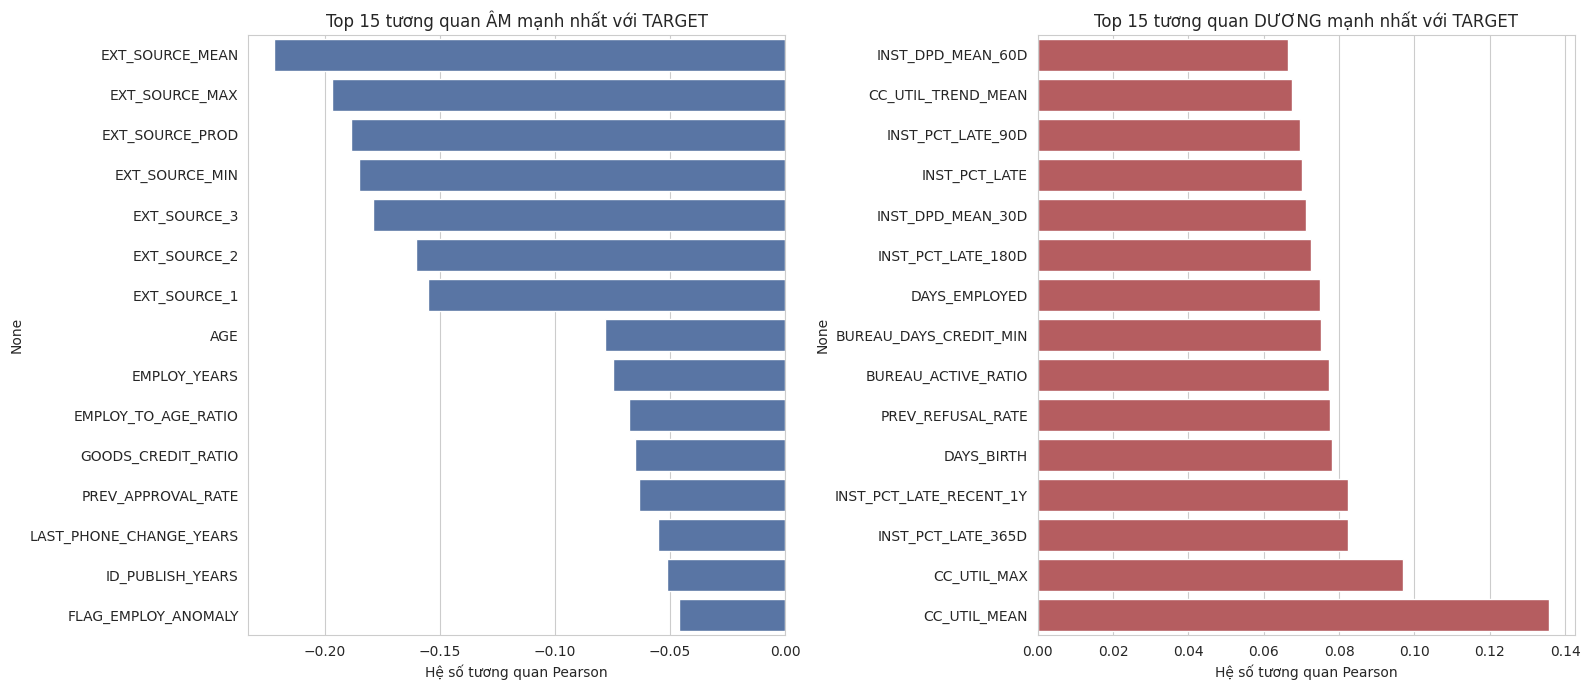

In [50]:
# Chỉ tính trên phần có TARGET (tập train)
train_part = master[master['TARGET'].notnull()].copy()
numeric_cols_master = train_part.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols_master = [c for c in numeric_cols_master if c not in ['SK_ID_CURR', 'TARGET']]

corr_with_target = train_part[numeric_cols_master + ['TARGET']].corr()['TARGET'].drop('TARGET').sort_values()

top_neg = corr_with_target.head(15)
top_pos = corr_with_target.tail(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.barplot(x=top_neg.values, y=top_neg.index, ax=axes[0], color='#4C72B0')
axes[0].set_title('Top 15 tương quan ÂM mạnh nhất với TARGET')
axes[0].set_xlabel('Hệ số tương quan Pearson')

sns.barplot(x=top_pos.values, y=top_pos.index, ax=axes[1], color='#C44E52')
axes[1].set_title('Top 15 tương quan DƯƠNG mạnh nhất với TARGET')
axes[1].set_xlabel('Hệ số tương quan Pearson')

plt.tight_layout()
plt.show()

**Đối chiếu với EDA (kỳ vọng):**
- `EXT_SOURCE_MEAN`/`MIN`/`MAX` nên nằm trong nhóm tương quan âm mạnh nhất (kế thừa từ EXT_SOURCE_1/2/3).
- `AGE`, `EMPLOY_YEARS` nên tương quan âm (tuổi/thâm niên cao → rủi ro thấp).
- `BUREAU_ACTIVE_RATIO`/`BUREAU_N_ACTIVE`, `PREV_REFUSAL_RATE`, `INST_PCT_LATE`, `CC_UTIL_MEAN` nên tương quan dương (hành vi xấu → rủi ro cao).
- Nếu một feature cho dấu **ngược lại kỳ vọng** hoặc gần 0 bất thường, quay lại kiểm tra công thức/logic tính toán trước khi dùng.

In [51]:
# In ra vị trí xếp hạng của các feature mới quan trọng để đối chiếu nhanh
key_new_features = [
    'EXT_SOURCE_MEAN', 'EXT_SOURCE_MIN', 'EXT_SOURCE_MAX', 'AGE', 'EMPLOY_YEARS',
    'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO',
    'HOUSING_QUALITY_SCORE', 'HOUSING_INFO_COMPLETENESS', 'ORGANIZATION_TYPE_FREQ',
    'BUREAU_N_ACTIVE', 'BUREAU_ACTIVE_RATIO', 'BUREAU_DEBT_CREDIT_RATIO', 'BUREAU_LATE_TREND_MEAN',
    'BUREAU_PCT_LATE_1M_MEAN', 'BUREAU_PCT_LATE_6M_MEAN', 'BUREAU_STATUS_DIFF3_MEAN',
    'PREV_APPROVAL_RATE', 'PREV_REFUSAL_RATE',
    'POS_DPD_MEAN', 'POS_DPD_TREND_MEAN', 'POS_PAID_LAST_1M_MEAN', 'POS_PAID_LAST_6M_MEAN',
    'POS_INSTALMENT_FUTURE_TREND_MEAN', 'POS_PAID_DPD_CORR_MEAN',
    'INST_PCT_LATE', 'INST_LATE_TREND',
    'INST_PCT_LATE_30D', 'INST_PCT_LATE_365D', 'INST_PAYMENT_SHARE_30D_MEAN', 'INST_PAYMENT_SHARE_365D_MEAN',
    'CC_UTIL_MEAN', 'CC_UTIL_TREND_MEAN', 'CC_UTIL_DIFF1_MEAN', 'CC_UTIL_DIFF6_MEAN',
    'CC_PAYMENT_TOTAL_TO_MIN_RATIO_MEAN', 'CC_UNDERPAID_MIN_RATE_MEAN',
    'CC_DRAWINGS_PAYMENT_RATIO_MEAN', 'CC_UTIL_DPD_CORR_MEAN', 'CC_DRAWINGS_PAYMENT_DPD_CORR_MEAN',
]
key_new_features = [f for f in key_new_features if f in corr_with_target.index]

print(f"{'Feature':<40}{'Tương quan với TARGET':>25}")
print('-' * 65)
for f in key_new_features:
    print(f'{f:<40}{corr_with_target[f]:>25.4f}')

Feature                                     Tương quan với TARGET
-----------------------------------------------------------------
EXT_SOURCE_MEAN                                           -0.2221
EXT_SOURCE_MIN                                            -0.1853
EXT_SOURCE_MAX                                            -0.1969
AGE                                                       -0.0782
EMPLOY_YEARS                                              -0.0750
CREDIT_INCOME_RATIO                                       -0.0077
ANNUITY_INCOME_RATIO                                       0.0143
HOUSING_QUALITY_SCORE                                     -0.0284
HOUSING_INFO_COMPLETENESS                                 -0.0399
ORGANIZATION_TYPE_FREQ                                     0.0010
BUREAU_N_ACTIVE                                            0.0436
BUREAU_ACTIVE_RATIO                                        0.0774
BUREAU_DEBT_CREDIT_RATIO                                   0.0602
BUREAU_LAT

## 11. Làm sạch lần cuối trước khi vào model

1. **Xử lý `inf`/`-inf`**: các phép chia (tỷ lệ) có thể sinh `inf` nếu mẫu số bằng 0 dù đã `.replace({0: np.nan})` ở hầu hết trường hợp — quét lại toàn bộ để chắc chắn.
2. **Encoding biến phân loại**: chuyển các cột `object` sang dtype `category` — LightGBM (bản sklearn API) tự nhận diện và xử lý categorical natively, không cần one-hot (tránh bùng nổ số chiều với `ORGANIZATION_TYPE_GROUPED`, `OCCUPATION_TYPE`...).
3. **Tách lại `train`/`test`** dựa trên `TARGET` (NaN = test).

In [52]:
numeric_master_cols = master.select_dtypes(include=[np.number]).columns
n_inf_before = np.isinf(master[numeric_master_cols]).sum().sum()
master[numeric_master_cols] = master[numeric_master_cols].replace([np.inf, -np.inf], np.nan)
print(f'Số giá trị inf đã thay bằng NaN: {n_inf_before}')

Số giá trị inf đã thay bằng NaN: 0


In [53]:
cat_cols = master.select_dtypes(include=['object']).columns.tolist()
print(f'Số cột categorical: {len(cat_cols)}')
for c in cat_cols:
    master[c] = master[c].astype('category')
print('Đã chuyển sang dtype category:', cat_cols)

Số cột categorical: 16
Đã chuyển sang dtype category: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE', 'ORGANIZATION_TYPE_GROUPED']


In [54]:
train_master = master[master['TARGET'].notnull()].copy()
test_master = master[master['TARGET'].isnull()].copy()
train_master['TARGET'] = train_master['TARGET'].astype(int)

print('train_master:', train_master.shape)
print('test_master :', test_master.shape)

feature_cols = [c for c in train_master.columns if c not in ['SK_ID_CURR', 'TARGET']]
print(f'Tổng số feature đưa vào model: {len(feature_cols)}')

train_master: (307511, 258)
test_master : (48744, 258)
Tổng số feature đưa vào model: 256


## 12. Train / Validation split

Dùng `stratify=y` để giữ nguyên tỷ lệ mất cân đối (~8% vỡ nợ) giữa tập train và validation — quan trọng với bài toán mất cân đối lớp.

In [55]:
from sklearn.model_selection import StratifiedKFold

X = train_master[feature_cols]
y = train_master['TARGET']

# Giữ 1 tập validation riêng, KHÔNG tham gia CV/tuning — dùng để đánh giá cuối cùng không thiên vị
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print('X_train:', X_train.shape, '| tỷ lệ TARGET=1:', y_train.mean().round(4))
print('X_val  :', X_val.shape, '| tỷ lệ TARGET=1:', y_val.mean().round(4))

# StratifiedKFold: giữ tỷ lệ mất cân đối lớp (~8%) đồng đều giữa các fold khi tuning
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

X_train: (246008, 256) | tỷ lệ TARGET=1: 0.0807
X_val  : (61503, 256) | tỷ lệ TARGET=1: 0.0807


## 13. Model — LightGBM

- `objective='binary'`, `metric='auc'` — bài toán phân loại nhị phân, đánh giá bằng AUC (phù hợp với dữ liệu mất cân đối hơn accuracy).
- `class_weight='balanced'` — tự động tăng trọng số cho lớp thiểu số (`TARGET=1`, ~8%) khi tính loss, giúp model không bị "lười" chỉ đoán toàn lớp đa số.
- `early_stopping` trên tập validation để tránh overfit mà không cần chọn số cây thủ công.
- Categorical features được LightGBM tự nhận diện từ dtype `category` đã set ở Phần 11.

In [56]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Không gian tham số để random search
param_distributions = {
    'num_leaves': randint(15, 127),
    'max_depth': randint(3, 12),
    'learning_rate': uniform(0.01, 0.19),      # 0.01 - 0.20
    'n_estimators': randint(200, 1000),        # thay cho early stopping (khó dùng chung với CV)
    'min_child_samples': randint(5, 100),
    'subsample': uniform(0.6, 0.4),            # 0.6 - 1.0
    'colsample_bytree': uniform(0.6, 0.4),     # 0.6 - 1.0
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(0, 1),
}

base_model = lgb.LGBMClassifier(
    objective='binary',
    class_weight='balanced',   # vẫn xử lý mất cân đối lớp như bản gốc
    random_state=RANDOM_STATE,
    n_jobs=1,                  # để n_jobs=1 ở đây, tránh oversubscribe CPU với n_jobs=-1 ở ngoài
    verbosity=-1,
)

random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_distributions,
    n_iter=30,          # số tổ hợp tham số thử — tăng nếu có thời gian/tài nguyên
    scoring='roc_auc',
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,           # song song hoá ở đây (ngoài)
    verbose=1,
    refit=True,          # tự fit lại model tốt nhất trên toàn bộ X_train
)

random_search.fit(X_train, y_train)

print('Best CV ROC-AUC (trung bình 5 fold):', round(random_search.best_score_, 4))
print('Best params:')
for k, v in random_search.best_params_.items():
    print(f'  {k}: {v}')

model = random_search.best_estimator_   # dùng biến `model` này cho các bước Evaluation phía sau (không đổi tên)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best CV ROC-AUC (trung bình 5 fold): 0.7843
Best params:
  colsample_bytree: 0.6915192661966489
  learning_rate: 0.024626182867470668
  max_depth: 5
  min_child_samples: 90
  n_estimators: 995
  num_leaves: 80
  reg_alpha: 0.6243540481337932
  reg_lambda: 0.295633685837714
  subsample: 0.6421977039321082


## 14. Evaluation — Confusion Matrix, Precision/Recall/Accuracy, ROC-AUC

**Lưu ý về ngưỡng phân loại (threshold):** với dữ liệu mất cân đối (~8% vỡ nợ), ngưỡng mặc định 0.5 thường khiến model quá "thận trọng" khi gán nhãn `1` — dẫn đến recall thấp dù AUC vẫn tốt. Notebook này báo cáo cả **ROC-AUC** (không phụ thuộc threshold, chỉ số chính để đánh giá tổng thể) lẫn **Precision/Recall/Accuracy tại threshold=0.5** (để có con số cụ thể tham khảo), và minh hoạ thêm cách chọn threshold khác nếu cần.

In [57]:
y_val_proba = model.predict_proba(X_val)[:, 1]
y_val_pred = (y_val_proba >= 0.51).astype(int)

roc_auc = roc_auc_score(y_val, y_val_proba)
acc = accuracy_score(y_val, y_val_pred)
prec = precision_score(y_val, y_val_pred)
rec = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)

print(f'ROC-AUC   : {roc_auc:.4f}')
print(f'Accuracy  : {acc:.4f}')
print(f'Precision : {prec:.4f}')
print(f'Recall    : {rec:.4f}')
print(f'F1-score  : {f1:.4f}')

ROC-AUC   : 0.7896
Accuracy  : 0.7586
Precision : 0.2009
Recall    : 0.6683
F1-score  : 0.3089


### 14.1 Confusion Matrix

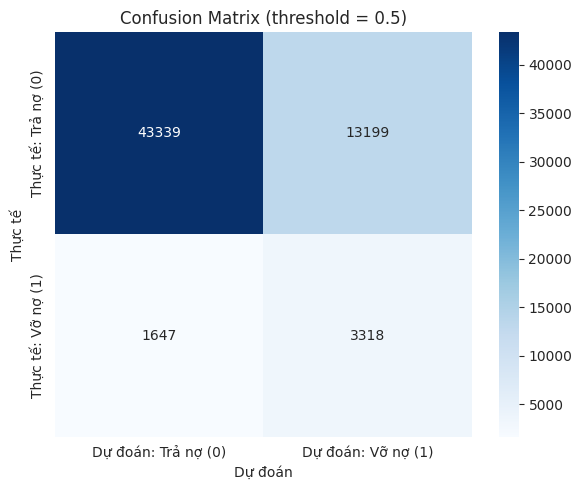

True Negative  (đoán đúng trả nợ)  : 43339
False Positive (đoán nhầm vỡ nợ)   : 13199  <- chi phí: từ chối oan khách tốt
False Negative (bỏ sót khách vỡ nợ): 1647  <- chi phí: duyệt nhầm khách xấu (thường tốn kém hơn)
True Positive  (đoán đúng vỡ nợ)   : 3318


In [58]:
cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Dự đoán: Trả nợ (0)', 'Dự đoán: Vỡ nợ (1)'],
            yticklabels=['Thực tế: Trả nợ (0)', 'Thực tế: Vỡ nợ (1)'])
plt.title(f'Confusion Matrix (threshold = 0.5)')
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negative  (đoán đúng trả nợ)  : {tn}')
print(f'False Positive (đoán nhầm vỡ nợ)   : {fp}  <- chi phí: từ chối oan khách tốt')
print(f'False Negative (bỏ sót khách vỡ nợ): {fn}  <- chi phí: duyệt nhầm khách xấu (thường tốn kém hơn)')
print(f'True Positive  (đoán đúng vỡ nợ)   : {tp}')

### 14.2 Classification Report (Precision / Recall / F1 / Accuracy đầy đủ theo từng lớp)

In [59]:
print(classification_report(y_val, y_val_pred, target_names=['Trả nợ (0)', 'Vỡ nợ (1)'], digits=4))

              precision    recall  f1-score   support

  Trả nợ (0)     0.9634    0.7665    0.8538     56538
   Vỡ nợ (1)     0.2009    0.6683    0.3089      4965

    accuracy                         0.7586     61503
   macro avg     0.5821    0.7174    0.5813     61503
weighted avg     0.9018    0.7586    0.8098     61503



### 14.3 ROC Curve & ROC-AUC

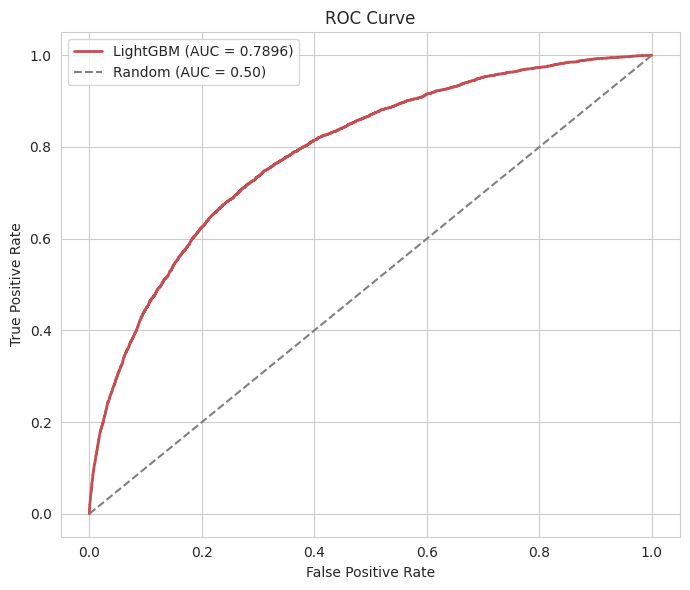

In [60]:
fpr, tpr, thresholds = roc_curve(y_val, y_val_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='#C44E52', linewidth=2, label=f'LightGBM (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

### 14.4 Precision-Recall Curve (bổ sung — phù hợp hơn ROC khi lớp dương rất hiếm)

Với dữ liệu mất cân đối mạnh (~8% dương), đường **Precision-Recall** thường phản ánh thực tế rõ hơn ROC (vì ROC có thể "trông đẹp" ngay cả khi precision thấp do TN quá nhiều).

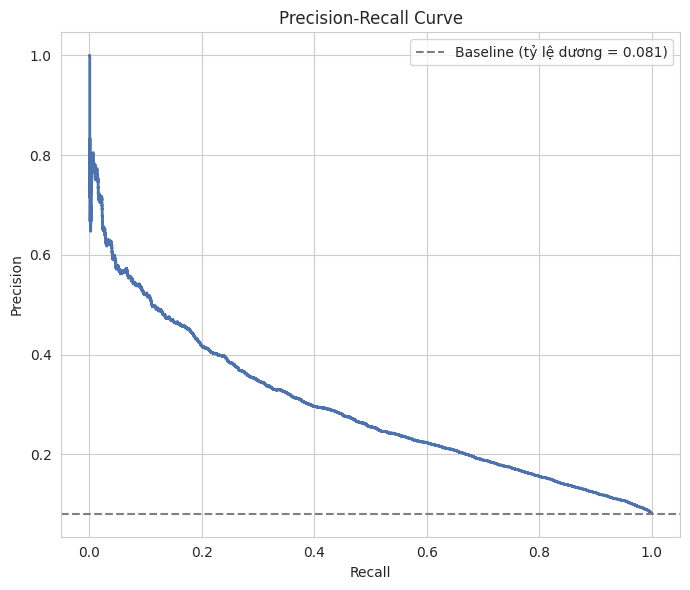

In [61]:
precisions, recalls, pr_thresholds = precision_recall_curve(y_val, y_val_proba)

plt.figure(figsize=(7, 6))
plt.plot(recalls, precisions, color='#4C72B0', linewidth=2)
plt.axhline(y_val.mean(), color='gray', linestyle='--', label=f'Baseline (tỷ lệ dương = {y_val.mean():.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.tight_layout()
plt.show()

### 14.5 Gợi ý chọn threshold khác 0.5 (tham khảo)

Ví dụ dùng chỉ số Youden's J (`TPR - FPR` lớn nhất) để chọn threshold cân bằng hơn giữa TPR và FPR — hữu ích khi mục tiêu nghiệp vụ ưu tiên bắt được nhiều khách rủi ro hơn (tăng recall), chấp nhận đánh đổi precision.

In [62]:
youden_j = tpr - fpr
best_idx = youden_j.argmax()
best_threshold = thresholds[best_idx]

print(f'Threshold tối ưu theo Youden J: {best_threshold:.4f} (so với mặc định 0.5)')
print(f'  Tại threshold này: TPR={tpr[best_idx]:.4f}, FPR={fpr[best_idx]:.4f}')

y_val_pred_opt = (y_val_proba >= best_threshold).astype(int)
print()
print(f'So sánh Recall:    threshold=0.5 -> {rec:.4f}   |   threshold tối ưu -> {recall_score(y_val, y_val_pred_opt):.4f}')
print(f'So sánh Precision: threshold=0.5 -> {prec:.4f}   |   threshold tối ưu -> {precision_score(y_val, y_val_pred_opt):.4f}')

Threshold tối ưu theo Youden J: 0.4680 (so với mặc định 0.5)
  Tại threshold này: TPR=0.7172, FPR=0.2793

So sánh Recall:    threshold=0.5 -> 0.6683   |   threshold tối ưu -> 0.7172
So sánh Precision: threshold=0.5 -> 0.2009   |   threshold tối ưu -> 0.1840


## 15. Feature Importance — đối chiếu lại với EDA

LightGBM cung cấp sẵn `feature_importances_` (mặc định tính theo **số lần một feature được dùng để chia nhánh** — `importance_type='split'`). Ta xem top 25 feature quan trọng nhất và đối chiếu với kỳ vọng từ EDA/mục 10.

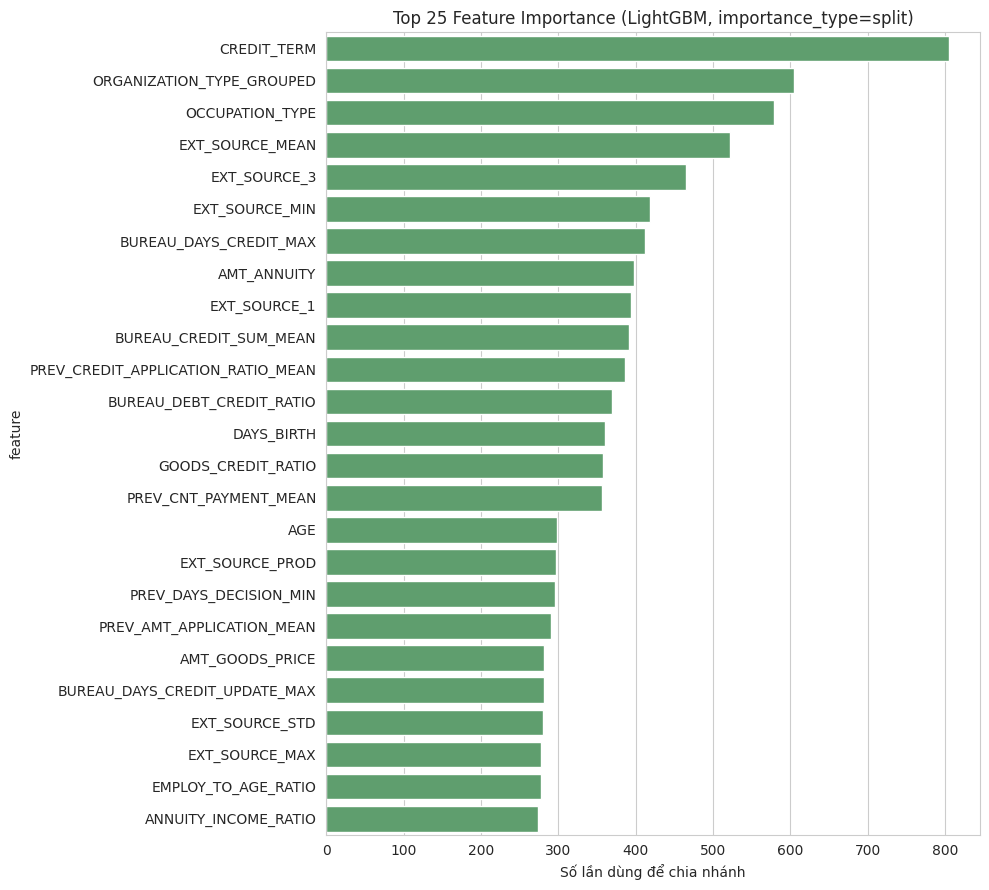

,feature,importance
87,CREDIT_TERM,805
77,ORGANIZATION_TYPE_GROUPED,605
26,OCCUPATION_TYPE,579
90,EXT_SOURCE_MEAN,522
40,EXT_SOURCE_3,465
92,EXT_SOURCE_MIN,419
143,BUREAU_DAYS_CREDIT_MAX,412
7,AMT_ANNUITY,398
38,EXT_SOURCE_1,394
139,BUREAU_CREDIT_SUM_MEAN,391


In [63]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_,
}).sort_values('importance', ascending=False)

top_n = 25
plt.figure(figsize=(10, 9))
sns.barplot(x='importance', y='feature', data=importance_df.head(top_n), color='#55A868')
plt.title(f'Top {top_n} Feature Importance (LightGBM, importance_type=split)')
plt.xlabel('Số lần dùng để chia nhánh')
plt.tight_layout()
plt.show()

importance_df.head(top_n)

**Đối chiếu nhanh với EDA:**
- Nhóm `EXT_SOURCE_*` (gốc + tổ hợp `EXT_SOURCE_MEAN/MIN/MAX`) và `AGE`/`EMPLOY_YEARS` được kỳ vọng nằm trong top đầu — khớp với phát hiện tương quan mạnh nhất ở EDA và mục 10.
- Các feature tổng hợp từ bảng phụ (`BUREAU_*`, `PREV_*`, `INST_*`, `CC_*`) xuất hiện trong top cho thấy việc ghép bảng phụ + tạo đặc trưng hành vi (Phần 4-8) **thực sự đóng góp giá trị dự báo** so với chỉ dùng riêng `application`.
- Nếu một nhóm feature tốn nhiều công tính (đặc biệt các đặc trưng trend từ bảng `_balance`) nhưng lại **không** lọt top quan trọng, đây là tín hiệu để cân nhắc bỏ bớt/đơn giản hoá ở vòng lặp tiếp theo — đánh đổi giữa độ phức tạp pipeline và giá trị thực tế mang lại.

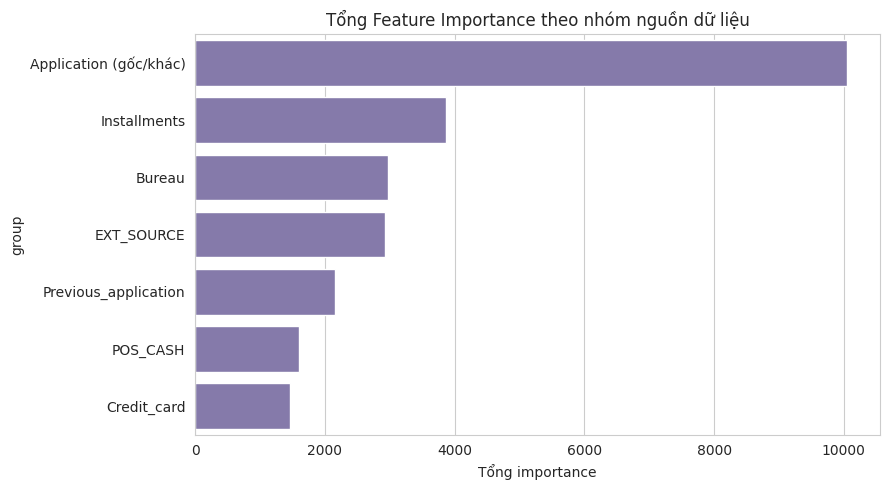

group
Application (gốc/khác)    10055
Installments               3868
Bureau                     2973
EXT_SOURCE                 2925
Previous_application       2161
POS_CASH                   1604
Credit_card                1456
Name: importance, dtype: int32

In [64]:
# Số lượng feature theo từng nhóm nguồn (dựa trên tiền tố tên cột) — giúp đánh giá đóng góp theo nhóm
def get_feature_group(name):
    prefixes = {
        'EXT_SOURCE': 'EXT_SOURCE', 'BUREAU_': 'Bureau', 'PREV_': 'Previous_application',
        'POS_': 'POS_CASH', 'INST_': 'Installments', 'CC_': 'Credit_card',
    }
    for p, g in prefixes.items():
        if name.startswith(p):
            return g
    return 'Application (gốc/khác)'

importance_df['group'] = importance_df['feature'].apply(get_feature_group)
group_importance = importance_df.groupby('group')['importance'].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=group_importance.values, y=group_importance.index, color='#8172B2')
plt.title('Tổng Feature Importance theo nhóm nguồn dữ liệu')
plt.xlabel('Tổng importance')
plt.tight_layout()
plt.show()

group_importance

## 16. (Bonus) Dự đoán trên tập `application_test`

Huấn luyện thêm một lần trên **toàn bộ** dữ liệu train (train+validation gộp lại, dùng `best_iteration_` đã xác định ở Phần 13 để tránh overfit) rồi dự đoán xác suất vỡ nợ cho tập test — theo đúng format nộp bài của cuộc thi Kaggle gốc (`SK_ID_CURR`, `TARGET` = xác suất).

In [65]:
final_model = lgb.LGBMClassifier(
    objective='binary', class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1,
    **random_search.best_params_,
)
final_model.fit(X, y)  # X, y = toàn bộ tập train (train_master)

X_test = test_master[feature_cols]
test_proba = final_model.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    'SK_ID_CURR': test_master['SK_ID_CURR'].astype(int),
    'TARGET': test_proba,
})

print(submission.head())
print()
print('Phân phối xác suất dự đoán trên tập test:')
print(submission['TARGET'].describe())

        SK_ID_CURR    TARGET
307511      100001  0.217927
307512      100005  0.645057
307513      100013  0.217348
307514      100028  0.304698
307515      100038  0.729179

Phân phối xác suất dự đoán trên tập test:
count    48744.000000
mean         0.363816
std          0.216826
min          0.005788
25%          0.184163
50%          0.322306
75%          0.520374
max          0.966087
Name: TARGET, dtype: float64


In [66]:
os.makedirs('/kaggle/working', exist_ok=True) if os.path.exists('/kaggle') else os.makedirs('./outputs', exist_ok=True)
out_path = '/kaggle/working/submission.csv' if os.path.exists('/kaggle') else './outputs/submission.csv'
submission.to_csv(out_path, index=False)
print('Đã lưu:', out_path)

Đã lưu: /kaggle/working/submission.csv


## 17. Kết luận & Hướng mở rộng

### Tóm tắt pipeline
1. **Data Cleaning**: xử lý anomaly `DAYS_EMPLOYED=365243`, gộp nhóm hiếm (`ORGANIZATION_TYPE` theo tiền tố ngành, các biến khác theo ngưỡng tần suất).
2. **Feature Engineering** theo 6 nguồn dữ liệu, tổng cộng nhiều nhóm đặc trưng: tỷ lệ tài chính, tổ hợp EXT_SOURCE, đặc trưng thời gian, và đặc trưng hành vi tổng hợp từ bureau/previous_application/POS_CASH/installments/credit_card — trong đó 3 bảng "_balance" được xử lý 2 bước (mức khoản vay → mức khách hàng) kèm **trend** (hệ số góc hồi quy tuyến tính theo thời gian).
3. Toàn bộ đặc trưng được **ghép về 1 bảng master theo `SK_ID_CURR`**, có phân biệt rõ cách điền missing cho cột đếm (0) và cột tỷ lệ (NaN).
4. **Kiểm tra tương quan** feature mới với TARGET trước khi train, đối chiếu với kỳ vọng từ EDA.
5. **Model**: LightGBM baseline, tham số cơ bản + `class_weight='balanced'` để xử lý mất cân đối, **chưa hyperparameter tuning**.
6. **Evaluation**: Confusion Matrix, Precision/Recall/Accuracy/F1 (tại threshold 0.5 và threshold tối ưu Youden's J), ROC-AUC + ROC curve, Precision-Recall curve, Feature Importance (theo feature và theo nhóm nguồn dữ liệu).

### Hướng mở rộng (gợi ý cho các bước tiếp theo)
- **Hyperparameter tuning**: dùng `Optuna`/`GridSearchCV`/`RandomizedSearchCV` để tối ưu `num_leaves`, `learning_rate`, `min_child_samples`, `subsample`, `colsample_bytree`...
- **Cross-validation**: thay single train/val split bằng `StratifiedKFold` (thường 5-fold) để đánh giá ổn định hơn và giảm phương sai do cách chia dữ liệu.
- **Thêm feature mới**: mở rộng thêm đặc trưng cho từng bảng phụ (vd phân loại theo `NAME_CONTRACT_TYPE`/`CREDIT_TYPE` cụ thể, thêm nhiều cửa sổ thời gian hơn — 3/6/12/24 tháng), hoặc thử tương tác giữa các feature quan trọng nhất (theo Phần 15).
- **Xử lý đa cộng tuyến**: rà soát lại các cặp feature tương quan cao (`AMT_CREDIT` vs `AMT_GOODS_PRICE`...) đã nêu ở phần tổng kết EDA, cân nhắc loại bớt nếu ảnh hưởng đến độ ổn định của model.
- **Model khác để so sánh**: thử XGBoost, CatBoost (xử lý categorical tốt), hoặc stacking/ensemble nhiều model.
- **Calibration xác suất**: nếu cần xác suất dự đoán chính xác về mặt xác suất (không chỉ xếp hạng), cân nhắc `CalibratedClassifierCV`.
- **Giải thích mô hình**: dùng SHAP (`shap.TreeExplainer`) để giải thích dự đoán ở mức từng khách hàng — hữu ích khi cần minh bạch hoá quyết định chấm điểm tín dụng.
- **Data leakage / PSI**: trước khi triển khai thực tế, kiểm tra lại rò rỉ dữ liệu (đặc biệt các feature từ `previous_application` phát sinh sau ngày quyết định) và tính ổn định phân phối theo thời gian (PSI) như đã đề cập ở EDA.

### Cách mở rộng notebook này
Nhờ cấu trúc rõ theo từng Phần (2 → 8 tương ứng từng bảng dữ liệu), khi cần thêm/sửa đặc trưng:
- Thêm feature mới cho 1 bảng → chỉnh trực tiếp trong mục tương ứng (vd thêm feature bureau mới → sửa Phần 4.3), sau đó chạy lại từ đó trở đi.
- Thêm bảng dữ liệu mới hoàn toàn → thêm 1 mục mới theo đúng khuôn mẫu (load → data cleaning riêng nếu cần → feature engineering có giải thích ý nghĩa → aggregate về `SK_ID_CURR`), rồi thêm vào bước ghép ở Phần 9.
